<a href="https://colab.research.google.com/github/princz003/SAINTGITS_lab_data/blob/main/Discrete_Mathematics_Lab_Manual.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---

# **SAINTGITS COLLEGE OF ENGINEERING (AUTONOMOUS)**

---

# **LABORATORY MANUAL**

# **Discrete Mathematical Structures**
### Computer Science and Engineering – Python Implementation

| | |
|---|---|
| **Programming language** | Python 3 (Jupyter Notebook / Google Colab) |
| **Libraries used** | SymPy, NumPy, Pandas, NetworkX, Matplotlib, SciPy, `itertools`, `heapq` |
| **Number of experiments** | 10 |

---

# **Institution Vision and Mission**

*(Insert the approved Vision and Mission statements of the Institution / Department here.)*

# **Details of Laboratory Equipment**

* Computers with Python 3.x and Jupyter Notebook (or Google Colab in a web browser)
* Python libraries: **SymPy, NumPy, Pandas, NetworkX, Matplotlib, SciPy** (all pre-installed on Google Colab); `itertools` and `heapq` are part of Python

# **List of Experiments**

| Exp. No. | Title of the Experiment | Area |
|---|---|---|
| 1 | Introducing Python libraries for discrete mathematical structures | Tools |
| 2 | Constructing the truth table of different compound statements in propositional logic | Logic |
| 3 | Verification of tautology and contradiction in propositional logic using Python | Logic |
| 4 | Plotting the graph of elementary mathematical functions | Functions |
| 5 | Hasse diagrams of partially ordered sets (posets) | Relations and orders |
| 6 | Plotting different types of directed and undirected graphs with proper labelling | Graph theory |
| 7 | Matrix representation of graphs (adjacency and incidence matrices) | Graph theory |
| 8 | Minimum spanning tree algorithms: Prim's and Kruskal's | Graph algorithms |
| 9 | Dijkstra's algorithm for the shortest path | Graph algorithms |
| 10 | Graph colouring using the greedy algorithm | Graph algorithms |

> **How to use this manual:** run every code cell in order (Shift + Enter). Read the short note above each cell, observe the output, and then attempt the practice problems at the end of each experiment. Graph layouts use a fixed *seed* so that your pictures match the manual.

---

# **EXPERIMENT 1**

---

# **Introducing Python Libraries for Discrete Mathematical Structures**

# **Aim:**

To explore the Python libraries that are effective tools for discrete mathematical structures — propositional logic, set operations, combinatorics, graph theory, visualisation and optimisation.

# **Software required:**

Python 3, SymPy, NumPy, NetworkX, Matplotlib, `itertools` (built-in), SciPy (PyEDA optional)

# **Theory:**

Discrete mathematics deals with *countable, distinct* structures — sets, logic, combinatorics and graphs — rather than continuous ones. Each library targets one of these areas:

| Library | Purpose | Used in |
|---|---|---|
| **SymPy** | symbolic logic: simplify Boolean expressions, truth tables, satisfiability, minimisation | Exp. 1–3 |
| **NumPy** | arrays, matrices, Boolean-array logic, set operations on arrays, counting | Exp. 1, 4, 7 |
| **Pandas** | tables of data, e.g. truth tables | Exp. 2, 3, 8, 9 |
| **NetworkX** | building, analysing and drawing graphs | Exp. 5–10 |
| **Matplotlib** | visualisation of functions, graphs and sets | all experiments |
| **itertools** | permutations, combinations and Cartesian products without writing loops | Exp. 1, 2 |
| **SciPy** | optimisation, e.g. linear programming | Exp. 1 |
| **heapq** | priority queues for graph algorithms | Exp. 8, 9 |

# **Procedure:**

* Simplify a Boolean expression, build a truth table and test equivalence with SymPy.
* Count combinations and permutations, use Boolean arrays and set operations with NumPy.
* Create a graph, test connectivity and find shortest paths with NetworkX; draw graphs and a Venn diagram with Matplotlib.
* Generate permutations, combinations, Cartesian products and the power set with `itertools`.
* Solve a linear-programming problem with SciPy and minimise a Boolean function with SymPy.

# **1. SymPy**

**Purpose:** symbolic logic manipulation, simplifying Boolean expressions, generating truth tables and checking equivalence. Below we simplify $p\wedge(\neg p\vee q)$ and confirm that it reduces to $p\wedge q$.

In [ ]:
from sympy import symbols, And, Or, Not, Implies, Equivalent, simplify, simplify_logic

# Propositions
p, q = symbols('p q')

# Logical expression
expr = And(p, Or(Not(p), q))

# Simplify the expression
simplified_expr = simplify(expr)
print("Original expression   :", expr)
print("Simplified expression :", simplified_expr)
print("Equivalent to p ∧ q ? :", bool(simplify_logic(Equivalent(expr, And(p, q)))))

Original expression   : p & (q | ~p)
Simplified expression : p & q
Equivalent to p ∧ q ? : True


In [ ]:
# Truth table of the expression
from sympy.logic.boolalg import truth_table

print(" p  q |  p ∧ (¬p ∨ q)")
print("-" * 22)
for inputs, output in truth_table(expr, [p, q]):
    print(f" {inputs[0]}  {inputs[1]} |  {int(bool(output))}")

 p  q |  p ∧ (¬p ∨ q)
----------------------
 0  0 |  0
 0  1 |  0
 1  0 |  0
 1  1 |  1


**Note:** now simplify the XOR expression $(A\wedge\neg B)\vee(\neg A\wedge B)$. It is already in its simplest sum-of-products form, so SymPy leaves it unchanged.

In [ ]:
A_, B_ = symbols('A B')
xor_expr = (A_ & ~B_) | (~A_ & B_)           # XOR operation
print("Expression            :", xor_expr)
print("After simplify_logic  :", simplify_logic(xor_expr))

print("\n A  B | A XOR B")
print("-" * 16)
for inputs, output in truth_table(xor_expr, [A_, B_]):
    print(f" {inputs[0]}  {inputs[1]} |   {int(bool(output))}")

Expression            : (A & ~B) | (B & ~A)
After simplify_logic  : (A & ~B) | (B & ~A)

 A  B | A XOR B
----------------
 0  0 |   0
 0  1 |   1
 1  0 |   1
 1  1 |   0


# **2. NumPy**

**Purpose:** matrix/array operations, quick combinatorics, Boolean-array logic and set operations.

Number of combinations $C(n,r)=\dfrac{n!}{r!(n-r)!}$ and permutations $P(n,r)=\dfrac{n!}{(n-r)!}$:

In [ ]:
import numpy as np
from math import comb, perm, factorial

n, r = 5, 3
print(f"Combinations C({n},{r}) = {comb(n, r)}      (formula: {factorial(n) // (factorial(r) * factorial(n - r))})")
print(f"Permutations P({n},{r}) = {perm(n, r)}      (formula: {factorial(n) // factorial(n - r)})")

Combinations C(5,3) = 10      (formula: 10)
Permutations P(5,3) = 60      (formula: 60)


**Note:** NumPy Boolean arrays support element-wise logical operations directly.

In [ ]:
A_arr = np.array([True, False, True])
B_arr = np.array([False, True, True])

print("A            :", A_arr)
print("B            :", B_arr)
print("Logical AND  :", np.logical_and(A_arr, B_arr))
print("Logical OR   :", np.logical_or(A_arr, B_arr))
print("Logical XOR  :", np.logical_xor(A_arr, B_arr))
print("Logical NOT A:", np.logical_not(A_arr))

A            : [ True False  True]
B            : [False  True  True]
Logical AND  : [False False  True]
Logical OR   : [ True  True  True]
Logical XOR  : [ True  True False]
Logical NOT A: [False  True False]


**Note:** `union1d`, `intersect1d`, `setdiff1d` and `setxor1d` give the set operations $A\cup B$, $A\cap B$, $A-B$ and $A\triangle B$ directly on arrays; `isin` tests membership.

In [ ]:
set_A = np.array([1, 2, 3])
set_B = np.array([3, 4, 5])

print("A = ", set_A, "   B = ", set_B)
print("Union A ∪ B               :", np.union1d(set_A, set_B))
print("Intersection A ∩ B        :", np.intersect1d(set_A, set_B))
print("Difference A − B          :", np.setdiff1d(set_A, set_B))
print("Symmetric difference A △ B:", np.setxor1d(set_A, set_B))
print("Is 3 in A?  :", bool(np.isin(3, set_A)), "     Is 4 in A? :", bool(np.isin(4, set_A)))

A =  [1 2 3]    B =  [3 4 5]
Union A ∪ B               : [1 2 3 4 5]
Intersection A ∩ B        : [3]
Difference A − B          : [1 2]
Symmetric difference A △ B: [1 2 4 5]
Is 3 in A?  : True      Is 4 in A? : False


# **3. NetworkX**

**Purpose:** build graphs, test connectivity and find shortest paths. Below is a 4-cycle graph (1–2–3–4–1); we check that it is connected and find the shortest path from 1 to 3 (there are two of equal length).

In [ ]:
import networkx as nx

# Create a graph
G = nx.Graph()
G.add_edges_from([(1, 2), (2, 3), (3, 4), (4, 1)])

print("Vertices :", list(G.nodes()))
print("Edges    :", list(G.edges()))
print("Degrees  :", dict(G.degree()))
print(f"Is the graph connected? {nx.is_connected(G)}")

path = nx.shortest_path(G, source=1, target=3)
print(f"Shortest path from 1 to 3: {path}   (length {len(path) - 1})")
print("All shortest paths from 1 to 3:", list(nx.all_shortest_paths(G, 1, 3)))

Vertices : [1, 2, 3, 4]
Edges    : [(1, 2), (1, 4), (2, 3), (3, 4)]
Degrees  : {1: 2, 2: 2, 3: 2, 4: 2}
Is the graph connected? True
Shortest path from 1 to 3: [1, 2, 3]   (length 2)
All shortest paths from 1 to 3: [[1, 2, 3], [1, 4, 3]]


# **4. Matplotlib**

**Purpose:** visualisation of discrete structures — graphs and relationships between sets.

* a directed 3-cycle graph and the ready-made cycle graph `nx.cycle_graph(5)`,
* a **Venn diagram** of the sets $A=\{1,2,3\}$ and $B=\{3,4,5\}$ drawn with overlapping circles.

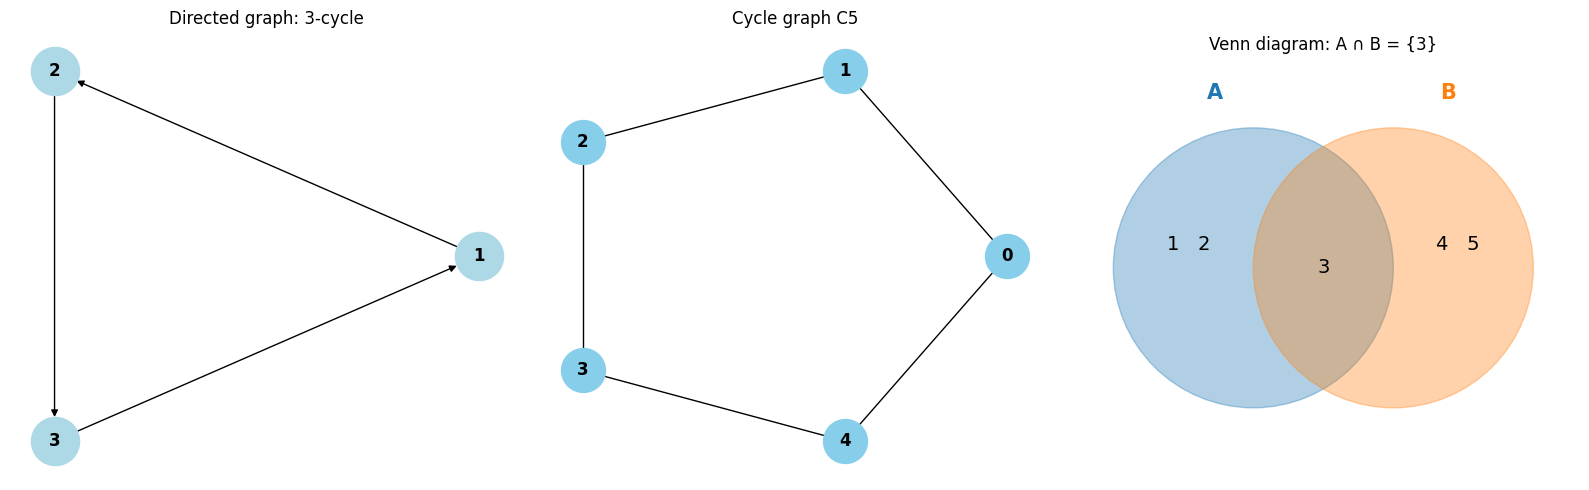

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

fig, ax = plt.subplots(1, 3, figsize=(16, 5))

# (a) directed graph
DG = nx.DiGraph()
DG.add_edges_from([(1, 2), (2, 3), (3, 1)])
nx.draw(DG, nx.circular_layout(DG), with_labels=True, node_color='lightblue', node_size=1200,
        font_weight='bold', arrows=True, ax=ax[0])
ax[0].set_title('Directed graph: 3-cycle')

# (b) cycle graph C5
C5 = nx.cycle_graph(5)
nx.draw(C5, nx.circular_layout(C5), with_labels=True, node_color='skyblue', node_size=1000,
        font_weight='bold', ax=ax[1])
ax[1].set_title('Cycle graph C5')

# (c) Venn diagram of A = {1,2,3}, B = {3,4,5}
ax[2].add_patch(Circle((-0.6, 0), 1.2, color='tab:blue', alpha=0.35))
ax[2].add_patch(Circle((0.6, 0), 1.2, color='tab:orange', alpha=0.35))
ax[2].text(-1.15, 0.15, '1   2', ha='center', fontsize=14); ax[2].text(0, 0, '3', ha='center', va='center', fontsize=14)
ax[2].text(1.15, 0.15, '4   5', ha='center', fontsize=14)
ax[2].text(-1.0, 1.45, 'A', fontsize=15, fontweight='bold', color='tab:blue'); ax[2].text(1.0, 1.45, 'B', fontsize=15, fontweight='bold', color='tab:orange')
ax[2].set_xlim(-2.2, 2.2); ax[2].set_ylim(-1.6, 1.8); ax[2].set_aspect('equal'); ax[2].axis('off')
ax[2].set_title('Venn diagram: A ∩ B = {3}')
plt.tight_layout()
plt.show()

# **5. itertools**

**Purpose:** generate permutations, combinations, Cartesian products and subsets without writing loops by hand. The number of items generated is checked against the counting formulas.

In [ ]:
from itertools import permutations, combinations, product, chain

elements = [1, 2, 3]

perm_list = list(permutations(elements))
print("Permutations of {1,2,3}      :", perm_list, "   count =", len(perm_list), "= 3!")

comb_list = list(combinations(elements, 2))
print("Combinations of 2 out of 3   :", comb_list, "   count =", len(comb_list), "= C(3,2)")

cart = list(product([1, 2], ['a', 'b', 'c']))
print("Cartesian product {1,2}×{a,b,c}:", cart, "   count =", len(cart), "= 2·3")

power_set = list(chain.from_iterable(combinations(elements, k) for k in range(len(elements) + 1)))
print("Power set of {1,2,3}         :", power_set, "   count =", len(power_set), "= 2^3")

Permutations of {1,2,3}      : [(1, 2, 3), (1, 3, 2), (2, 1, 3), (2, 3, 1), (3, 1, 2), (3, 2, 1)]    count = 6 = 3!
Combinations of 2 out of 3   : [(1, 2), (1, 3), (2, 3)]    count = 3 = C(3,2)
Cartesian product {1,2}×{a,b,c}: [(1, 'a'), (1, 'b'), (1, 'c'), (2, 'a'), (2, 'b'), (2, 'c')]    count = 6 = 2·3
Power set of {1,2,3}         : [(), (1,), (2,), (3,), (1, 2), (1, 3), (2, 3), (1, 2, 3)]    count = 8 = 2^3


# **6. SciPy**

**Purpose:** solve linear-programming (optimisation) problems. Maximise $x+2y$ subject to $2x+y\le20$, $x+2y\le20$ and $x,y\ge0$. `linprog` *minimises*, so the objective is negated. The feasible region and the optimum are then plotted.

Note that the objective line $x+2y=c$ is *parallel* to the constraint $x+2y\le20$; so when the objective reaches its maximum value $20$ it does so along a whole edge of the feasible region (**alternative optima**), and the solver reports one vertex of that edge.

Optimal solution reported: x = 0.0000, y = 10.0000
Maximum value of x + 2y = 20.0000

Objective x + 2y at the vertices of the feasible region:
  (0, 0)         -> 0.0000
  (10, 0)        -> 10.0000
  (20/3, 20/3)   -> 20.0000
  (0, 10)        -> 20.0000
Two vertices give the maximum 20, so every point of the edge joining them is optimal.


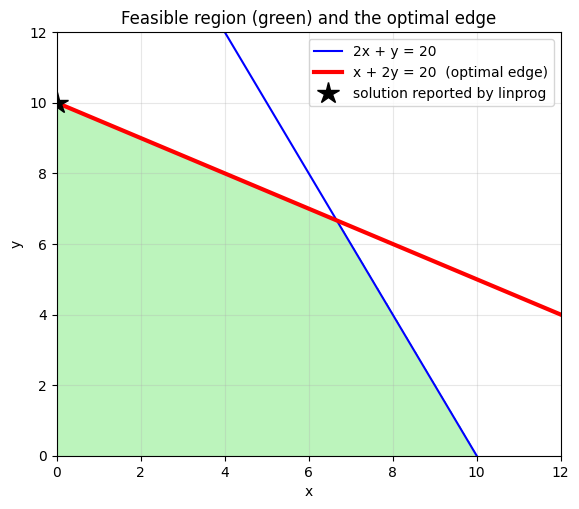

In [ ]:
from scipy.optimize import linprog

c = [-1, -2]                      # minimise -x - 2y  (i.e. maximise x + 2y)
A_ub = [[2, 1], [1, 2]]           # coefficients of the inequalities
b_ub = [20, 20]

result = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=[(0, None), (0, None)], method='highs')
print(f"Optimal solution reported: x = {result.x[0]:.4f}, y = {result.x[1]:.4f}")
print(f"Maximum value of x + 2y = {-result.fun:.4f}")

# value of the objective at every vertex of the feasible region
vertices = {"(0, 0)": (0, 0), "(10, 0)": (10, 0), "(20/3, 20/3)": (20 / 3, 20 / 3), "(0, 10)": (0, 10)}
print("\nObjective x + 2y at the vertices of the feasible region:")
for name, (vx, vy) in vertices.items():
    print(f"  {name:14s} -> {vx + 2 * vy:.4f}")
print("Two vertices give the maximum 20, so every point of the edge joining them is optimal.")

xx = np.linspace(0, 12, 400)
X, Y = np.meshgrid(xx, xx)
feasible = (2 * X + Y <= 20) & (X + 2 * Y <= 20)

plt.figure(figsize=(6.5, 5.5))
plt.contourf(X, Y, feasible, levels=[0.5, 1.5], colors=['lightgreen'], alpha=0.6)
plt.plot(xx, 20 - 2 * xx, 'b-', label='2x + y = 20'); plt.plot(xx, (20 - xx) / 2, 'r-', lw=3, label='x + 2y = 20  (optimal edge)')
plt.plot(*result.x, 'k*', ms=16, label='solution reported by linprog')
plt.xlim(0, 12); plt.ylim(0, 12); plt.xlabel('x'); plt.ylabel('y'); plt.grid(True, alpha=0.3); plt.legend()
plt.title('Feasible region (green) and the optimal edge')
plt.show()

# **7. Boolean minimisation (Karnaugh map level)**

**Purpose:** Boolean algebra at the electronic-design level — find the *minimal sum-of-products* of a function from its minterms. SymPy's `SOPform` does what a Karnaugh map does by hand. (The specialised package **PyEDA** offers the same with larger functions; it can be installed with `pip install pyeda` and used as `from pyeda.inter import exprvar, espresso_exprs`. It is not required for this manual.)

**Example:** $f(x,y,z)=\sum m(1,3,5,6,7)$ — the function is 1 for the input rows 001, 011, 101, 110, 111.

In [ ]:
import pandas as pd
from sympy.logic import SOPform

x, y, z = symbols('x y z')
minterms = [[0, 0, 1], [0, 1, 1], [1, 0, 1], [1, 1, 0], [1, 1, 1]]
minimal = SOPform([x, y, z], minterms)
print("Minimal sum of products:", minimal)

# Karnaugh map: rows = x, columns = yz in Gray-code order
gray = ['00', '01', '11', '10']
kmap = pd.DataFrame([[int([x_, int(c[0]), int(c[1])] in minterms) for c in gray] for x_ in (0, 1)],
                    index=['x = 0', 'x = 1'], columns=[f'yz = {c}' for c in gray])
print("\nKarnaugh map of f(x, y, z):")
display(kmap)
print("The four 1s in the column z = 1 form one group (term z); the two adjacent 1s at x = 1, y = 1 form the group x·y.")

# verify that the minimal expression equals the original function on all 8 inputs
from itertools import product
ok = all(bool(minimal.subs({x: a, y: b, z: c})) == ([a, b, c] in minterms) for a, b, c in product([0, 1], repeat=3))
print("Minimal expression reproduces f on all 8 inputs:", ok)

Minimal sum of products: z | (x & y)

Karnaugh map of f(x, y, z):


,yz = 00,yz = 01,yz = 11,yz = 10
x = 0,0,1,1,0
x = 1,0,1,1,1


The four 1s in the column z = 1 form one group (term z); the two adjacent 1s at x = 1, y = 1 form the group x·y.
Minimal expression reproduces f on all 8 inputs: True


# **Result**

All the libraries — SymPy, NumPy, NetworkX, Matplotlib, `itertools`, SciPy (and SymPy's Boolean minimiser in place of PyEDA) — were demonstrated with working, verified code and output, covering logic ($p\wedge(\neg p\vee q)\equiv p\wedge q$), set operations, combinatorics ($C(5,3)=10$, $P(5,3)=60$), graph theory (the 4-cycle is connected, shortest path $1\to3$ has length 2), visualisation (graphs and a Venn diagram), optimisation (the maximum of $x+2y$ is $20$, attained along the whole edge $x+2y=20$ from $(0,10)$ to $(20/3,20/3)$) and logic minimisation ($f=z+xy$).

# **Discussion**

Each library handles one family of discrete structures with a few lines of code, and they work together: NetworkX builds the graph, Matplotlib draws it, SciPy optimises over it. SymPy works *symbolically* (exact logical expressions) while NumPy works *numerically* on arrays. The counts produced by `itertools` ($3!$ permutations, $C(3,2)$ combinations, $2\cdot3$ pairs, $2^3$ subsets) agree with the counting formulas, which is a useful way to check a combinatorial formula.

# **Practice Problems**

**Problem 1.** Use SymPy to simplify $(p\vee q)\wedge(p\vee\neg q)$ and check with a truth table that your answer is equivalent.

**Problem 2.** With NumPy, find $A\cup B$, $A\cap B$, $A-B$ and $A\triangle B$ for $A=\{2,4,6,8,10\}$ and $B=\{3,6,9\}$, and verify that $|A\cup B|=|A|+|B|-|A\cap B|$.

**Problem 3.** Using `itertools`, list all 3-letter arrangements of the letters of `{a, b, c, d}` and all 2-element subsets; verify the counts with `math.perm(4, 3)` and `math.comb(4, 2)`.

**Problem 4.** Build the complete graph $K_5$ with `nx.complete_graph(5)`, draw it, and verify that it has $\binom52=10$ edges and that every vertex has degree 4.

---

# **EXPERIMENT 2**

---

# **Constructing the Truth Table of Different Compound Statements in Propositional Logic**

# **Aim:**

To construct the truth tables of compound statements in propositional logic using Python, for any number of propositional variables.

# **Software required:**

Python 3, Pandas, `itertools`, `inspect`

# **Theory:**

A **proposition** is a statement that is either true (T) or false (F). Compound statements are formed with the logical connectives:

| Connective | Symbol | Python | True when |
|---|---|---|---|
| Negation | $\neg A$ | `not A` | $A$ is false |
| Conjunction | $A\wedge B$ | `A and B` | both are true |
| Disjunction | $A\vee B$ | `A or B` | at least one is true |
| Implication | $A\to B$ | `(not A) or B` | not ($A$ true and $B$ false) |
| Biconditional | $A\leftrightarrow B$ | `A == B` | $A$ and $B$ have the same truth value |
| Exclusive OR | $A\oplus B$ | `A != B` | exactly one is true |

A **truth table** lists the value of a compound statement for *every* assignment of truth values to its variables. With $n$ variables there are $2^n$ rows.

# **Algorithm:**

1. Import the required libraries (`pandas`, `itertools`, `inspect`).
2. Define the function `generate_truth_table(*expressions)`; each argument is a pair *(name, function)*.
3. Read the variable names from the parameters of the first function and compute the number of rows $2^n$.
4. Generate all combinations of truth values with `itertools.product([False, True], repeat=n)`.
5. Evaluate every expression on every row and store the results as columns of a Pandas DataFrame.
6. Display the truth table.

# **Step 1: Import the required libraries**

* *pandas* handles tabular data — here it builds and displays the truth table as a DataFrame.
* *itertools.product* generates all combinations of truth values.
* *inspect.signature* reads the names of the variables from the parameters of a function.

In [ ]:
import pandas as pd
import inspect
from itertools import product

# **Step 2: The function `generate_truth_table`**

**Step 2.1 – Define the function.** `generate_truth_table(*expressions)` takes any number of compound expressions, each a tuple `(name, function)`.

**Step 2.2 – Variables and rows.** `variables` = the parameter names of the first function; $n=$ number of variables; there are $2^n$ rows.

**Step 2.3 – Truth values of the variables.** `product([False, True], repeat=n)` gives every combination, with the first row all False and the last row all True.

**Step 2.4 – Evaluate each expression** row by row and store the results in a column named after the expression.

**Step 2.5 – Return the table** as a Pandas DataFrame.

In [ ]:
def generate_truth_table(*expressions):
    # Variable names = parameter names of the first function
    variables = list(inspect.signature(expressions[0][1]).parameters)
    n = len(variables)

    # All 2^n combinations of truth values (first row: all False)
    rows = list(product([False, True], repeat=n))
    data = {var: [row[j] for row in rows] for j, var in enumerate(variables)}

    # Evaluate every compound expression on every row
    for name, func in expressions:
        data[name] = [bool(func(*row)) for row in rows]

    return pd.DataFrame(data)

def show(table):
    """Display a truth table with T / F instead of True / False."""
    display(table.apply(lambda col: col.map({True: 'T', False: 'F'})))

# **Step 3: Define the compound statements**

Five compound statements of two variables $A,B$ — OR, AND, NOT, implication and biconditional.

In [ ]:
truth_table = generate_truth_table(
    ("A ∨ B", lambda A, B: A or B),             # Logical OR
    ("A ∧ B", lambda A, B: A and B),            # Logical AND
    ("¬A",    lambda A, B: not A),              # Logical NOT
    ("A → B", lambda A, B: (not A) or B),       # Implication
    ("A ↔ B", lambda A, B: A == B),             # Biconditional
)
print("Number of rows =", len(truth_table), "= 2^2")

Number of rows = 4 = 2^2


# **Step 4: Print and display the truth table**

The raw DataFrame shows `True`/`False`; the function `show` prints the same table with the usual symbols T and F. Note that $A\to B$ is false only in the row $A=T,B=F$, and $A\leftrightarrow B$ is true exactly when $A$ and $B$ agree.

In [ ]:
print(truth_table)

       A      B  A ∨ B  A ∧ B     ¬A  A → B  A ↔ B
0  False  False  False  False   True   True   True
1  False   True   True  False   True   True  False
2   True  False   True  False  False  False  False
3   True   True   True   True  False   True   True


In [ ]:
show(truth_table)

,A,B,A ∨ B,A ∧ B,¬A,A → B,A ↔ B
0,F,F,F,F,T,T,T
1,F,T,T,F,T,T,F
2,T,F,T,F,F,F,F
3,T,T,T,T,F,T,T


# **Example 2 – Login system**

Using `generate_truth_table()`, construct the truth table for a login system's access rule $A\wedge(B\vee C)$, where $A=$ "username is valid", $B=$ "password is correct" and $C=$ "valid OTP provided", and identify all input combinations under which access is granted. Two more compound statements, $(A\to B)\wedge(B\to C)$ and $\neg A\vee\neg B$, are evaluated on the same 8 rows.

In [ ]:
login = generate_truth_table(
    ("A ∧ (B ∨ C)",       lambda A, B, C: A and (B or C)),                 # access rule
    ("(A → B) ∧ (B → C)", lambda A, B, C: (not A or B) and (not B or C)),  # conjunction of implications
    ("¬A ∨ ¬B",           lambda A, B, C: not A or not B),                 # disjunction of negations
)
print("Number of rows =", len(login), "= 2^3")
show(login)

granted = login[login["A ∧ (B ∨ C)"]][["A", "B", "C"]]
print(f"Access is granted in {len(granted)} of {len(login)} input combinations:")
show(granted)

Number of rows = 8 = 2^3


,A,B,C,A ∧ (B ∨ C),(A → B) ∧ (B → C),¬A ∨ ¬B
0,F,F,F,F,T,T
1,F,F,T,F,T,T
2,F,T,F,F,F,T
3,F,T,T,F,T,T
4,T,F,F,F,F,T
5,T,F,T,T,F,T
6,T,T,F,T,F,F
7,T,T,T,T,T,F


Access is granted in 3 of 8 input combinations:


,A,B,C
5,T,F,T
6,T,T,F
7,T,T,T


# **Logical equivalence with truth tables**

Two statements are **logically equivalent** if their columns are identical in the truth table. De Morgan's laws and the equivalence of an implication with its contrapositive are checked below.

In [ ]:
laws = generate_truth_table(
    ("¬(A ∧ B)",      lambda A, B: not (A and B)),
    ("¬A ∨ ¬B",       lambda A, B: (not A) or (not B)),
    ("¬(A ∨ B)",      lambda A, B: not (A or B)),
    ("¬A ∧ ¬B",       lambda A, B: (not A) and (not B)),
    ("A → B",         lambda A, B: (not A) or B),
    ("¬B → ¬A",       lambda A, B: B or (not A)),
)
show(laws)
print("¬(A ∧ B) ≡ ¬A ∨ ¬B   :", laws["¬(A ∧ B)"].equals(laws["¬A ∨ ¬B"]))
print("¬(A ∨ B) ≡ ¬A ∧ ¬B   :", laws["¬(A ∨ B)"].equals(laws["¬A ∧ ¬B"]))
print("A → B ≡ ¬B → ¬A      :", laws["A → B"].equals(laws["¬B → ¬A"]))

,A,B,¬(A ∧ B),¬A ∨ ¬B,¬(A ∨ B),¬A ∧ ¬B,A → B,¬B → ¬A
0,F,F,T,T,T,T,T,T
1,F,T,T,T,F,F,T,T
2,T,F,T,T,F,F,F,F
3,T,T,F,F,F,F,T,T


¬(A ∧ B) ≡ ¬A ∨ ¬B   : True
¬(A ∨ B) ≡ ¬A ∧ ¬B   : True
A → B ≡ ¬B → ¬A      : True


# **Result**

Python programs using Pandas and `itertools` generated the truth tables of compound propositional statements automatically: five two-variable expressions ($A\vee B$, $A\wedge B$, $\neg A$, $A\to B$, $A\leftrightarrow B$; 4 rows) and three three-variable expressions ($A\wedge(B\vee C)$, $(A\to B)\wedge(B\to C)$, $\neg A\vee\neg B$; 8 rows). The outputs matched the expected logical identities ($A\to B$ is false only for $A=T$, $B=F$; $A\leftrightarrow B$ is true exactly when $A$ and $B$ agree). The login rule $A\wedge(B\vee C)$ grants access in 3 of the 8 combinations, and De Morgan's laws and the contrapositive law were verified by comparing columns.

# **Discussion**

The function generalises to any number of variables: the variable names are read from the parameters of the first lambda, so a new expression needs no code changes — only a new `(name, function)` pair. The table grows as $2^n$ rows, which is exactly why automation matters once $n\ge3$: it replaces error-prone manual enumeration. Separating the *logic* (the lambda) from the *truth-table machinery* lets one function handle OR, AND, NOT, implication, biconditional and arbitrary nested combinations unchanged — the same exhaustive-evaluation principle used by SAT solvers and hardware-verification tools to prove that, for example, an access rule never over-grants.

# **Practice Problems**

**Problem 1.** In digital circuit design, a three-input logic gate is defined with the function $f(A,B,C)=A\wedge(B\vee C)$. A fault is suspected when the gate does not output True for some expected input combinations. Using the truth-table generation algorithm, construct the truth table for the function. Identify the input conditions under which the gate should ideally output True, and compare it with observed outputs to detect inconsistencies.

**Problem 2.** A software system's access-control guard is implemented as: access is granted if the user is an admin, OR if the user is a manager AND the request is during business hours. Let $p=$ "user is admin", $q=$ "user is a manager", $r=$ "request is during business hours", so the guard is $p\vee(q\wedge r)$. Using the truth-table generation algorithm, construct the truth table for this expression, identify the input combinations under which access should be granted, and use the table to check whether a logged decision that denied access to an admin user ($p=$ True) making a request outside business hours ($r=$ False) is consistent with the intended policy.

**Problem 3.** Use `generate_truth_table` to show that $A\to(B\to C)$ and $(A\wedge B)\to C$ are logically equivalent, and that $A\to(B\to C)$ and $(A\to B)\to C$ are **not**.

---

# **EXPERIMENT 3**

---

# **Verification of Tautology and Contradiction in Propositional Logic Using Python**

# **Aim:**

To verify whether a given compound propositional statement is a **tautology** (true for all cases), a **contradiction** (false for all cases) or neither, using Python.

# **Software required:**

Python 3, Pandas, SymPy (for an independent check)

# **Theory:**

* **Tautology:** a proposition that is true for *all* possible truth-value assignments to its variables.
* **Contradiction:** a proposition that is false for *all* possible truth-value assignments.
* **Contingency (satisfiable):** true for at least one assignment and false for at least one — neither of the above.
* **Satisfiable:** true for at least one assignment (tautologies and contingencies are satisfiable).

**Logical operators**

* $\neg$ (NOT): negates a proposition.
* $\wedge$ (AND): true if both propositions are true.
* $\vee$ (OR): true if at least one proposition is true.
* $\to$ (implies): true except when the first proposition is true and the second is false; $P\to Q\equiv\neg P\vee Q$.
* $\leftrightarrow$ (equivalent): true if both propositions have the same truth value.

**Useful facts:** $P$ is a tautology $\iff\neg P$ is a contradiction; $P$ is a contradiction $\iff\neg P$ is a tautology; $P\equiv Q$ $\iff$ $P\leftrightarrow Q$ is a tautology.

# **Requirements:**

Python 3 with Pandas (for the truth tables) and SymPy (`pip install sympy`, pre-installed on Colab) for logical operations.

# **Procedure:**

1. Define the logical proposition and decompose it into parts (left-hand side, right-hand side, full implication).
2. List the propositional variables.
3. Create the truth table: list all combinations of truth values and evaluate every sub-expression.
4. Analyse the final column: all True $\Rightarrow$ tautology; all False $\Rightarrow$ contradiction; otherwise contingency (satisfiable).
5. Automate steps 3–4 in Python and cross-check the answer with SymPy's satisfiability test.

# **The functions used in the examples**

`generate_truth_table` is the function of Experiment 2. `analyse` prints the truth table of a proposition, classifies it, and lists the assignments that make it **false** (the *counter-examples* to being a tautology).

In [ ]:
import pandas as pd
import inspect
from itertools import product

def generate_truth_table(*expressions):
    variables = list(inspect.signature(expressions[0][1]).parameters)
    rows = list(product([False, True], repeat=len(variables)))
    data = {var: [row[j] for row in rows] for j, var in enumerate(variables)}
    for name, func in expressions:
        data[name] = [bool(func(*row)) for row in rows]
    return pd.DataFrame(data)

def show(table):
    display(table.apply(lambda col: col.map({True: 'T', False: 'F'})))

def classify(column):
    if column.all():
        return "Tautology"
    if not column.any():
        return "Contradiction"
    return "Contingency (satisfiable but not a tautology)"

def analyse(name, *parts):
    """parts: (label, function) pairs; the LAST pair is the full proposition."""
    table = generate_truth_table(*parts)
    show(table)
    final = table[parts[-1][0]]
    variables = list(inspect.signature(parts[0][1]).parameters)
    print(f"Proposition : {name}")
    print(f"True in {int(final.sum())} of {len(final)} rows  ->  {classify(final)}")
    if not final.all():
        counter = table[~final][variables]
        print("Assignments that make it FALSE:", counter.to_dict('records'))
    return table

# **Example 1**

Verify whether the compound proposition

$$((P\vee Q)\wedge(\neg Q\vee R))\to((P\wedge R)\vee\neg Q)$$

is a tautology, a contradiction or neither. It is decomposed into LHS $=(P\vee Q)\wedge(\neg Q\vee R)$, RHS $=(P\wedge R)\vee\neg Q$, and the implication LHS $\to$ RHS $\equiv\neg$LHS $\vee$ RHS.

In [ ]:
t1 = analyse("((P ∨ Q) ∧ (¬Q ∨ R)) → ((P ∧ R) ∨ ¬Q)",
    ("LHS: (P ∨ Q) ∧ (¬Q ∨ R)", lambda P, Q, R: (P or Q) and (not Q or R)),
    ("RHS: (P ∧ R) ∨ ¬Q",       lambda P, Q, R: (P and R) or (not Q)),
    ("LHS → RHS",               lambda P, Q, R: not ((P or Q) and (not Q or R)) or ((P and R) or (not Q))))

,P,Q,R,LHS: (P ∨ Q) ∧ (¬Q ∨ R),RHS: (P ∧ R) ∨ ¬Q,LHS → RHS
0,F,F,F,F,T,T
1,F,F,T,F,T,T
2,F,T,F,F,F,T
3,F,T,T,T,F,F
4,T,F,F,T,T,T
5,T,F,T,T,T,T
6,T,T,F,F,F,T
7,T,T,T,T,T,T


Proposition : ((P ∨ Q) ∧ (¬Q ∨ R)) → ((P ∧ R) ∨ ¬Q)
True in 7 of 8 rows  ->  Contingency (satisfiable but not a tautology)
Assignments that make it FALSE: [{'P': False, 'Q': True, 'R': True}]


**Observation.** The proposition is false for $P=F,\,Q=T,\,R=T$: then LHS is true but RHS is false. Hence it is **not a tautology**; since it is true in the other rows it is **satisfiable** (a contingency).

# **Example 2**

Verify if the following proposition is a tautology: $\;(P\vee Q)\wedge(\neg P\vee Q)$.

In [ ]:
t2 = analyse("(P ∨ Q) ∧ (¬P ∨ Q)",
    ("Q (for comparison)",       lambda P, Q: Q),
    ("(P ∨ Q) ∧ (¬P ∨ Q)",      lambda P, Q: (P or Q) and (not P or Q)))
print("The final column is identical to the column of Q ->", t2["Q (for comparison)"].equals(t2["(P ∨ Q) ∧ (¬P ∨ Q)"]),
      "(the proposition simplifies to Q by the resolution rule).")

,P,Q,Q (for comparison),(P ∨ Q) ∧ (¬P ∨ Q)
0,F,F,F,F
1,F,T,T,T
2,T,F,F,F
3,T,T,T,T


Proposition : (P ∨ Q) ∧ (¬P ∨ Q)
True in 2 of 4 rows  ->  Contingency (satisfiable but not a tautology)
Assignments that make it FALSE: [{'P': False, 'Q': False}, {'P': True, 'Q': False}]
The final column is identical to the column of Q -> True (the proposition simplifies to Q by the resolution rule).


# **Example 3**

$$((P\vee Q)\wedge(\neg P\vee R))\to(Q\vee R)$$

This is the **resolution rule**, the basis of automated theorem provers.

In [ ]:
t3 = analyse("((P ∨ Q) ∧ (¬P ∨ R)) → (Q ∨ R)",
    ("LHS: (P ∨ Q) ∧ (¬P ∨ R)", lambda P, Q, R: (P or Q) and (not P or R)),
    ("RHS: Q ∨ R",              lambda P, Q, R: Q or R),
    ("Proposition",             lambda P, Q, R: not ((P or Q) and (not P or R)) or (Q or R)))

,P,Q,R,LHS: (P ∨ Q) ∧ (¬P ∨ R),RHS: Q ∨ R,Proposition
0,F,F,F,F,F,T
1,F,F,T,F,T,T
2,F,T,F,T,T,T
3,F,T,T,T,T,T
4,T,F,F,F,F,T
5,T,F,T,T,T,T
6,T,T,F,F,T,T
7,T,T,T,T,T,T


Proposition : ((P ∨ Q) ∧ (¬P ∨ R)) → (Q ∨ R)
True in 8 of 8 rows  ->  Tautology


# **Example 4**

$$P\wedge\neg P$$

(the law of non-contradiction).

In [ ]:
t4 = analyse("P ∧ ¬P",
    ("P",       lambda P: P),
    ("¬P",      lambda P: not P),
    ("P ∧ ¬P",  lambda P: P and not P))

,P,¬P,P ∧ ¬P
0,F,T,F
1,T,F,F


Proposition : P ∧ ¬P
True in 0 of 2 rows  ->  Contradiction
Assignments that make it FALSE: [{'P': False}, {'P': True}]


# **Cross-check with SymPy and a summary of classic laws**

SymPy decides tautology and contradiction by **satisfiability**: $P$ is a tautology iff $\neg P$ is *unsatisfiable*, and a contradiction iff $P$ itself is unsatisfiable. The table below classifies the four examples and several classic laws by both methods.

In [ ]:
from sympy import symbols, And, Or, Not, Implies, Equivalent
from sympy.logic.inference import satisfiable

P, Q, R = symbols('P Q R')

def sympy_classify(expr):
    if not satisfiable(Not(expr)):
        return "Tautology"
    if not satisfiable(expr):
        return "Contradiction"
    return "Contingency"

propositions = [
    ("Example 1: ((P∨Q)∧(¬Q∨R)) → ((P∧R)∨¬Q)", Implies(And(Or(P, Q), Or(Not(Q), R)), Or(And(P, R), Not(Q))),
        lambda P, Q, R: not ((P or Q) and (not Q or R)) or ((P and R) or (not Q))),
    ("Example 2: (P∨Q)∧(¬P∨Q)", And(Or(P, Q), Or(Not(P), Q)),
        lambda P, Q, R: (P or Q) and (not P or Q)),
    ("Example 3: ((P∨Q)∧(¬P∨R)) → (Q∨R)", Implies(And(Or(P, Q), Or(Not(P), R)), Or(Q, R)),
        lambda P, Q, R: not ((P or Q) and (not P or R)) or (Q or R)),
    ("Example 4: P ∧ ¬P", And(P, Not(P)),
        lambda P, Q, R: P and not P),
    ("Excluded middle: P ∨ ¬P", Or(P, Not(P)),
        lambda P, Q, R: P or not P),
    ("Contrapositive: (P→Q) ↔ (¬Q→¬P)", Equivalent(Implies(P, Q), Implies(Not(Q), Not(P))),
        lambda P, Q, R: ((not P) or Q) == (Q or (not P))),
    ("De Morgan: ¬(P∧Q) ↔ (¬P∨¬Q)", Equivalent(Not(And(P, Q)), Or(Not(P), Not(Q))),
        lambda P, Q, R: (not (P and Q)) == ((not P) or (not Q))),
    ("Modus ponens: (P ∧ (P→Q)) → Q", Implies(And(P, Implies(P, Q)), Q),
        lambda P, Q, R: not (P and ((not P) or Q)) or Q),
    ("Fallacy: (P→Q) → (Q→P)", Implies(Implies(P, Q), Implies(Q, P)),
        lambda P, Q, R: not ((not P) or Q) or ((not Q) or P)),
    ("P ∧ (P → ¬P)  [contradiction]", And(P, Implies(P, Not(P))),
        lambda P, Q, R: P and ((not P) or (not P))),
]

rows = []
for name, sym_expr, func in propositions:
    col = generate_truth_table(("v", func))["v"]
    rows.append({"Proposition": name, "Truth-table method": classify(col).split(" (")[0],
                 "SymPy (satisfiability)": sympy_classify(sym_expr)})
summary = pd.DataFrame(rows).set_index("Proposition")
summary["Agree?"] = summary["Truth-table method"] == summary["SymPy (satisfiability)"]
display(summary)

,Truth-table method,SymPy (satisfiability),Agree?
Proposition,,,
Example 1: ((P∨Q)∧(¬Q∨R)) → ((P∧R)∨¬Q),Contingency,Contingency,True
Example 2: (P∨Q)∧(¬P∨Q),Contingency,Contingency,True
Example 3: ((P∨Q)∧(¬P∨R)) → (Q∨R),Tautology,Tautology,True
Example 4: P ∧ ¬P,Contradiction,Contradiction,True
Excluded middle: P ∨ ¬P,Tautology,Tautology,True
Contrapositive: (P→Q) ↔ (¬Q→¬P),Tautology,Tautology,True
De Morgan: ¬(P∧Q) ↔ (¬P∨¬Q),Tautology,Tautology,True
Modus ponens: (P ∧ (P→Q)) → Q,Tautology,Tautology,True
Fallacy: (P→Q) → (Q→P),Contingency,Contingency,True


# **Result**

* Example 1, $((P\vee Q)\wedge(\neg Q\vee R))\to((P\wedge R)\vee\neg Q)$: **not a tautology** (false for $P=F,Q=T,R=T$); it is satisfiable — a contingency.
* Example 2, $(P\vee Q)\wedge(\neg P\vee Q)$: **not a tautology**; it is equivalent to $Q$ (a contingency).
* Example 3, $((P\vee Q)\wedge(\neg P\vee R))\to(Q\vee R)$: a **tautology** (true in all 8 rows).
* Example 4, $P\wedge\neg P$: a **contradiction** (false in both rows).
* The truth-table method and SymPy's satisfiability test gave the same classification for all ten propositions.

# **Discussion**

The classification only needs the final column of the truth table: all True means tautology, all False means contradiction, a mixture means contingency. A single row with value False is enough to refute a claimed tautology, and the counter-example printed by `analyse` shows exactly why the claim fails. The truth-table method needs $2^n$ rows, while SAT solvers (SymPy's `satisfiable`) avoid listing all rows by search and propagation — the idea behind automated verification of hardware and software. Tautologies such as modus ponens and the resolution rule are the *valid rules of inference* used in proofs.

# **Practice Problems**

**Problem 1.** Classify the following propositions as tautology, contradiction or contingency using truth tables, and check your answers with SymPy: (i) $(P\to Q)\vee(Q\to P)$, (ii) $(P\wedge Q)\wedge\neg(P\vee Q)$, (iii) $(P\to Q)\wedge(Q\to R)\to(P\to R)$ (hypothetical syllogism).

**Problem 2.** Show by truth table that $\neg(P\leftrightarrow Q)$ is equivalent to $P\oplus Q$, and that $P\to(Q\vee R)$ is equivalent to $(P\wedge\neg Q)\to R$.

**Problem 3.** Write a function `is_valid_argument(premises, conclusion)` that checks whether the argument "premises $\Rightarrow$ conclusion" is valid, i.e. whether $(\text{premise}_1\wedge\dots\wedge\text{premise}_k)\to\text{conclusion}$ is a tautology. Test it on modus tollens: $P\to Q,\ \neg Q\ \therefore\ \neg P$.

---

# **EXPERIMENT 4**

---

# **Plotting the Graph of Elementary Mathematical Functions**

# **Aim:**

To plot and visualise the graphs of elementary mathematical functions — quadratic, sine, cosine, exponential and logarithmic — and of combinations of them, and to read off their properties (domain, range, symmetry, behaviour near a discontinuity) from the graphs.

# **Software required:**

Python 3, NumPy, Matplotlib

# **Theory:**

A **function** $f:X\to Y$ assigns to every element of the domain $X$ exactly one element of $Y$; its graph is the set of points $(x,f(x))$.

| Function | Formula | Domain | Range | Notes |
|---|---|---|---|---|
| Quadratic | $f(x)=x^2$ | $\mathbb R$ | $[0,\infty)$ | even; parabola opening upwards |
| Sine | $f(x)=\sin x$ | $\mathbb R$ | $[-1,1]$ | odd; period $2\pi$ |
| Cosine | $f(x)=\cos x$ | $\mathbb R$ | $[-1,1]$ | even; period $2\pi$; $\cos x=\sin(x+\pi/2)$ |
| Exponential | $f(x)=e^{x}$ | $\mathbb R$ | $(0,\infty)$ | increasing, one-to-one |
| Logarithmic | $f(x)=\ln x$ | $(0,\infty)$ | $\mathbb R$ | inverse of $e^x$; undefined for $x\le0$ |

* A function is **even** if $f(-x)=f(x)$ (graph symmetric about the $y$-axis) and **odd** if $f(-x)=-f(x)$ (symmetric about the origin).
* A one-to-one function $f$ and its inverse $f^{-1}$ have graphs that are mirror images in the line $y=x$.
* Near a point where the formula is undefined (e.g. $\dfrac{1}{x+1}$ at $x=-1$) the graph has a vertical **asymptote**.

# **Algorithm:**

1. Import NumPy and `matplotlib.pyplot`.
2. Define the ranges of $x$ with `np.linspace`:
   * quadratic and exponential: `np.linspace(-10, 10, 400)`
   * sine and cosine: `np.linspace(0, 2*np.pi, 400)`
   * logarithmic: `np.linspace(0.1, 10, 400)` (positive values only)
3. Compute the function values $y_1=x^2$, $y_2=\sin x$, $y_3=\cos x$, $y_4=e^x$, $y_5=\ln x$.
4. Create subplots with `plt.subplots()` and plot each pair $(x,y)$ in its own panel.
5. Add labels, titles, grid and legend; adjust the layout with `plt.tight_layout()`.
6. Display the plot with `plt.show()`.

# **4.1 A single function**

The quadratic function $f(x)=x^2$ on $[-10,10]$.

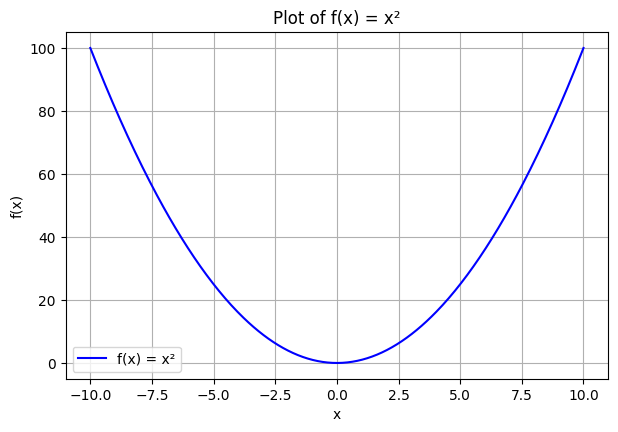

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define the range of x values
x1 = np.linspace(-10, 10, 400)
y1 = x1 ** 2                     # quadratic function f(x) = x^2

plt.figure(figsize=(7, 4.5))
plt.plot(x1, y1, label='f(x) = x²', color='blue')
plt.xlabel('x'); plt.ylabel('f(x)'); plt.title('Plot of f(x) = x²')
plt.grid(True); plt.legend()
plt.show()

# **4.2 The five elementary functions**

The five functions are drawn on a $3\times2$ grid of subplots. Each function uses its own range of $x$. The sixth panel shows $e^x$ on a *logarithmic* $y$-axis, where an exponential function becomes a **straight line**.

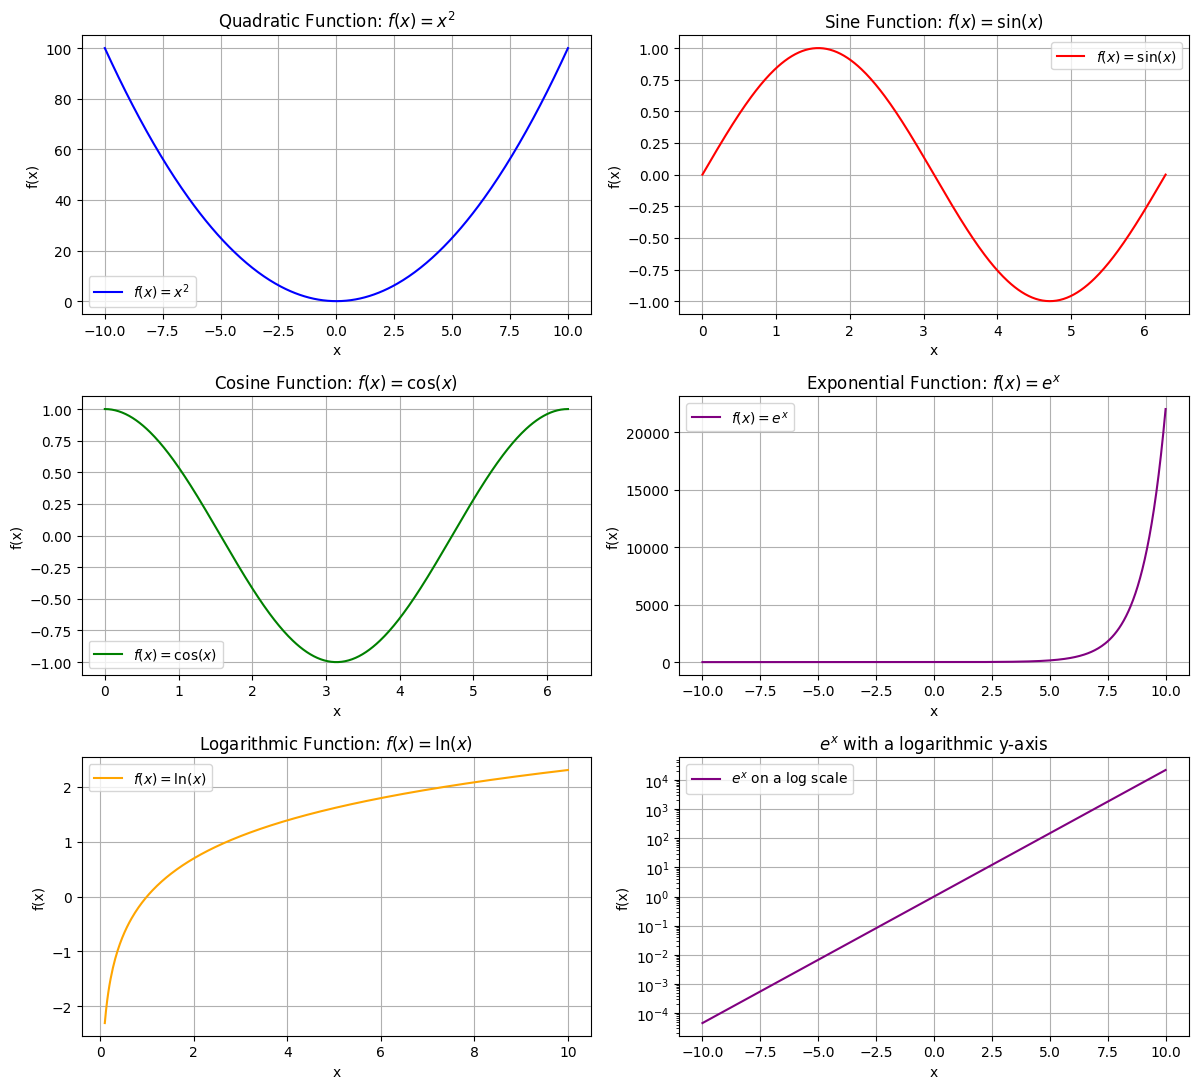

In [ ]:
# Ranges of x for each function
x1 = np.linspace(-10, 10, 400)        # quadratic and exponential
x2 = np.linspace(0, 2 * np.pi, 400)   # sine and cosine
x3 = np.linspace(0.1, 10, 400)        # logarithmic (x > 0)

# The mathematical functions
y1 = x1 ** 2                          # quadratic
y2 = np.sin(x2)                       # sine
y3 = np.cos(x2)                       # cosine
y4 = np.exp(x1)                       # exponential
y5 = np.log(x3)                       # logarithmic

fig, ax = plt.subplots(3, 2, figsize=(12, 11))

ax[0, 0].plot(x1, y1, label=r'$f(x) = x^2$', color='b');         ax[0, 0].set_title('Quadratic Function: $f(x) = x^2$')
ax[0, 1].plot(x2, y2, label=r'$f(x) = \sin(x)$', color='r');     ax[0, 1].set_title(r'Sine Function: $f(x) = \sin(x)$')
ax[1, 0].plot(x2, y3, label=r'$f(x) = \cos(x)$', color='g');     ax[1, 0].set_title(r'Cosine Function: $f(x) = \cos(x)$')
ax[1, 1].plot(x1, y4, label=r'$f(x) = e^x$', color='purple');    ax[1, 1].set_title('Exponential Function: $f(x) = e^x$')
ax[2, 0].plot(x3, y5, label=r'$f(x) = \ln(x)$', color='orange'); ax[2, 0].set_title(r'Logarithmic Function: $f(x) = \ln(x)$')
ax[2, 1].semilogy(x1, y4, label=r'$e^x$ on a log scale', color='purple'); ax[2, 1].set_title('$e^x$ with a logarithmic y-axis')

for a in ax.ravel():
    a.set_xlabel('x'); a.set_ylabel('f(x)'); a.grid(True); a.legend()
plt.tight_layout()
plt.show()

**Results and observations**

* **Quadratic:** a symmetric parabola opening upwards with its minimum $0$ at $x=0$.
* **Sine:** oscillates between $-1$ and $1$ with period $2\pi$.
* **Cosine:** the same shape as sine shifted by $90^\circ$ ($\pi/2$).
* **Exponential:** grows rapidly for positive $x$ and decays towards (but never reaches) $0$ for negative $x$.
* **Logarithmic:** increases slowly for positive $x$, crosses zero at $x=1$ and is undefined for $x\le0$.

# **4.3 Verifying properties numerically**

Symmetry and inverse relations are checked with numbers, and the inverse pair $e^x$ and $\ln x$ is drawn together with the line $y=x$ — the graphs are mirror images in that line.

Even / odd tests  (f(-x) compared with f(x) and -f(x))
  x²    : even = True   odd = False  -> even
  sin x : even = False  odd = True   -> odd
  cos x : even = True   odd = False  -> even
  e^x   : even = False  odd = False  -> neither even nor odd

Inverse functions:   ln(e^x) = x :  True     e^(ln x) = x (x > 0) : True
Identity sin²x + cos²x = 1 : True
Shift: cos x = sin(x + π/2): True


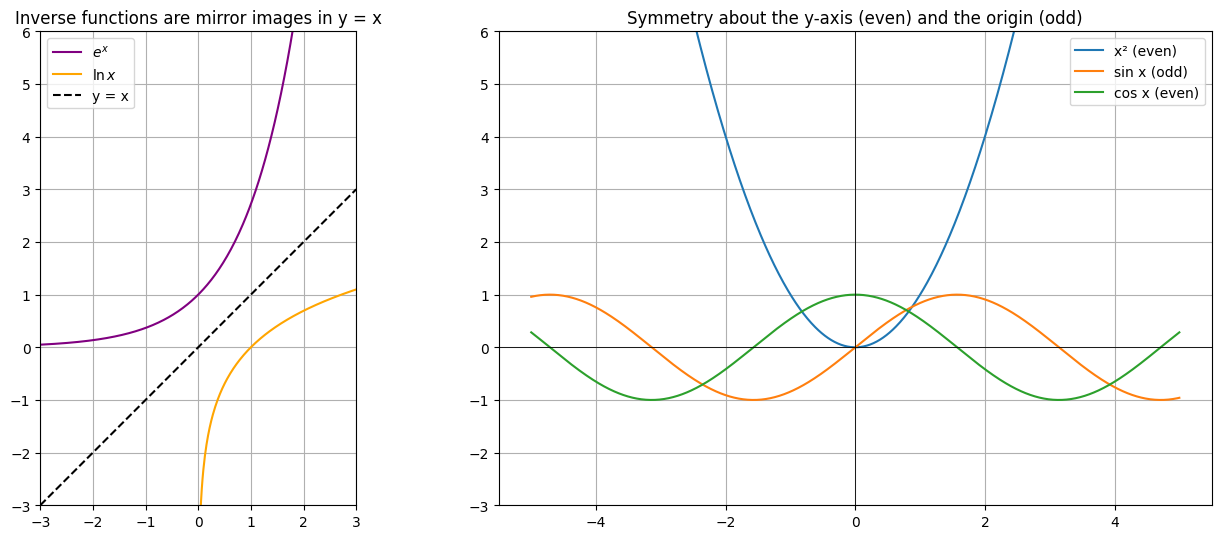

In [ ]:
x = np.linspace(-5, 5, 1001)
xp = np.linspace(0.01, 5, 500)

print("Even / odd tests  (f(-x) compared with f(x) and -f(x))")
for name, f in (("x²", lambda t: t ** 2), ("sin x", np.sin), ("cos x", np.cos), ("e^x", np.exp)):
    even, odd = np.allclose(f(-x), f(x)), np.allclose(f(-x), -f(x))
    print(f"  {name:6s}: even = {even!s:5s}  odd = {odd!s:5s}  ->", "even" if even else "odd" if odd else "neither even nor odd")

print("\nInverse functions:   ln(e^x) = x : ", np.allclose(np.log(np.exp(x)), x),
      "    e^(ln x) = x (x > 0) :", np.allclose(np.exp(np.log(xp)), xp))
print("Identity sin²x + cos²x = 1 :", np.allclose(np.sin(x) ** 2 + np.cos(x) ** 2, 1))
print("Shift: cos x = sin(x + π/2):", np.allclose(np.cos(x), np.sin(x + np.pi / 2)))

fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))
t = np.linspace(-3, 3, 400)
ax[0].plot(t, np.exp(t), 'purple', label=r'$e^x$')
ax[0].plot(t[t > 0.02], np.log(t[t > 0.02]), 'orange', label=r'$\ln x$')
ax[0].plot(t, t, 'k--', label='y = x')
ax[0].set_xlim(-3, 3); ax[0].set_ylim(-3, 6); ax[0].set_aspect('equal'); ax[0].grid(True); ax[0].legend()
ax[0].set_title('Inverse functions are mirror images in y = x')

ax[1].plot(x, x ** 2, label='x² (even)'); ax[1].plot(x, np.sin(x), label='sin x (odd)'); ax[1].plot(x, np.cos(x), label='cos x (even)')
ax[1].set_ylim(-3, 6); ax[1].axhline(0, color='k', lw=0.6); ax[1].axvline(0, color='k', lw=0.6); ax[1].grid(True); ax[1].legend()
ax[1].set_title('Symmetry about the y-axis (even) and the origin (odd)')
plt.tight_layout()
plt.show()

# **Example – a function with a vertical asymptote**

$$f(x)=2x^3-3x^2+5\sin x+\frac{4}{x+1}$$

The term $\dfrac{4}{x+1}$ is undefined at $x=-1$. Removing only the single point $x=-1$ from the $x$ array would still join the points on either side of the asymptote with a line; to show the break correctly the values near $x=-1$ are set to `NaN`, which Matplotlib does not connect.

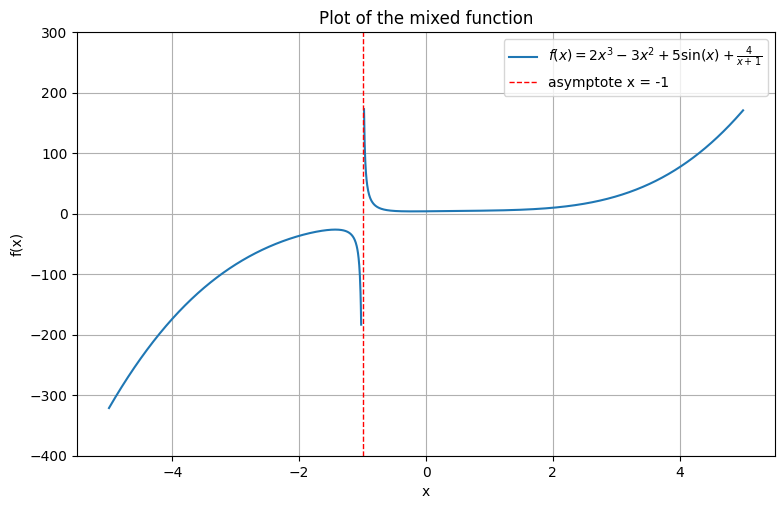

In [ ]:
def f(x):
    return 2 * x ** 3 - 3 * x ** 2 + 5 * np.sin(x) + 4 / (x + 1)

x = np.linspace(-5, 5, 2000)
y = f(x)
y[np.abs(x + 1) < 0.02] = np.nan            # break the curve at the asymptote x = -1

plt.figure(figsize=(9, 5.5))
plt.plot(x, y, label=r'$f(x) = 2x^3 - 3x^2 + 5\sin(x) + \frac{4}{x+1}$')
plt.axvline(-1, color='red', ls='--', lw=1, label='asymptote x = -1')
plt.ylim(-400, 300)
plt.title('Plot of the mixed function'); plt.xlabel('x'); plt.ylabel('f(x)'); plt.grid(True); plt.legend()
plt.show()

# **Application – plotting several functions together**

Plot the following functions on the same axes:

* Quadratic: $f_1(x)=x^2-4x+4$
* Sine: $f_2(x)=\sin x$
* Exponential: $f_3(x)=e^x$
* Logarithmic: $f_4(x)=\ln(x+2)$ (defined only for $x>-2$)
* Rational: $f_5(x)=\dfrac{1}{x+2}$ (undefined at $x=-2$)

The domains must be respected: $f_4$ is drawn only for $x>-2$, and $f_5$ is broken at $x=-2$.

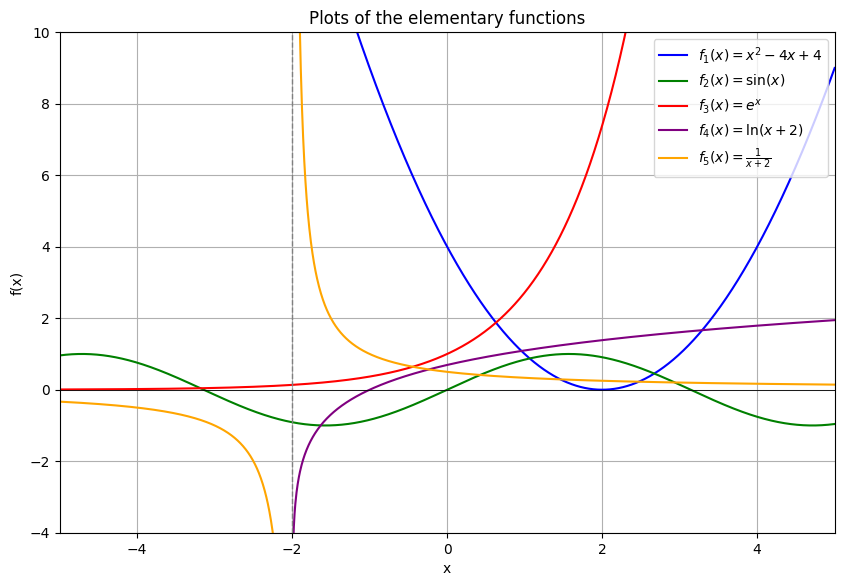

Domain of f4 = ln(x+2): x > -2        Domain of f5 = 1/(x+2): x ≠ -2        Value of f1 at its minimum x = 2: 0


In [ ]:
x = np.linspace(-5, 5, 2000)

f1 = x ** 2 - 4 * x + 4
f2 = np.sin(x)
f3 = np.exp(x)
with np.errstate(invalid='ignore', divide='ignore'):
    f4 = np.where(x > -2, np.log(x + 2), np.nan)                       # domain: x > -2
    f5 = np.where(np.abs(x + 2) > 0.02, 1 / (x + 2), np.nan)           # break at x = -2

plt.figure(figsize=(10, 6.5))
plt.plot(x, f1, label=r'$f_1(x) = x^2 - 4x + 4$', color='blue')
plt.plot(x, f2, label=r'$f_2(x) = \sin(x)$', color='green')
plt.plot(x, f3, label=r'$f_3(x) = e^x$', color='red')
plt.plot(x, f4, label=r'$f_4(x) = \ln(x+2)$', color='purple')
plt.plot(x, f5, label=r'$f_5(x) = \frac{1}{x+2}$', color='orange')
plt.axvline(-2, color='gray', ls='--', lw=1)
plt.ylim(-4, 10); plt.xlim(-5, 5)
plt.axhline(0, color='k', lw=0.6)
plt.title('Plots of the elementary functions'); plt.xlabel('x'); plt.ylabel('f(x)'); plt.grid(True); plt.legend(loc='upper right')
plt.show()
print("Domain of f4 = ln(x+2): x > -2        Domain of f5 = 1/(x+2): x ≠ -2        Value of f1 at its minimum x = 2:", (2 ** 2 - 4 * 2 + 4))

# **Result**

The graphs of the quadratic, sine, cosine, exponential and logarithmic functions were plotted with NumPy and Matplotlib, singly and in a grid of subplots; the symmetry (even/odd), inverse-function and trigonometric identities were verified numerically; the mixed function with a vertical asymptote at $x=-1$ and the five functions $f_1$–$f_5$ with their restricted domains were plotted correctly.

# **Discussion**

The shape of a graph reflects the properties of the function: the parabola and cosine are even, sine is odd, $e^x$ is positive and increasing, and $\ln x$ — its inverse — is its mirror image in $y=x$, which is why $\ln x$ grows so slowly and exists only for $x>0$. When a function is undefined at a point, the plotting code must respect the domain — by restricting the $x$ values (as for $\ln$) or by inserting `NaN` at an asymptote — otherwise Matplotlib draws a misleading line across the discontinuity. The logarithmic $y$-axis turns exponential growth into a straight line, a standard way of recognising exponential behaviour in data.

# **Practice Problems**

**Problem 1.** Plot $f(x)=\tan x$ on $[-2\pi,2\pi]$ so that the vertical asymptotes at $x=\pm\pi/2,\pm3\pi/2$ are not joined by lines (set $y$ to `NaN` where $|\cos x|<0.05$).

**Problem 2.** Plot $f(x)=x^3-3x$ and $g(x)=|x|$. Test numerically whether each is even, odd or neither.

**Problem 3.** Plot the floor and ceiling functions $\lfloor x\rfloor$ and $\lceil x\rceil$ on $[-3,3]$ (use `np.floor`, `np.ceil` and `plt.step`) and the *characteristic* function of the set of integers.

**Problem 4.** Plot $f(x)=2^x$, $g(x)=\log_2 x$ and the line $y=x$ and show that $g$ is the inverse of $f$.

---

# **EXPERIMENT 5**

---

# **Hasse Diagrams of Partially Ordered Sets (Posets)**

# **Aim:**

To define partially ordered sets (posets), to verify the three properties of a partial order, to compute the *cover relations*, and to draw the Hasse diagram of a poset using Python (NetworkX and Matplotlib).

# **Software required:**

Python 3, NetworkX, Matplotlib, Pandas

# **Theory:**

A **partial order** on a set $S$ is a relation $\preceq$ that is

* **reflexive:** $a\preceq a$ for all $a$;
* **antisymmetric:** $a\preceq b$ and $b\preceq a\Rightarrow a=b$;
* **transitive:** $a\preceq b$ and $b\preceq c\Rightarrow a\preceq c$.

$(S,\preceq)$ is then a **poset**. Two elements are *comparable* if $a\preceq b$ or $b\preceq a$.

**Hasse diagram.** A Hasse diagram represents a poset economically:

* every element is a vertex;
* an edge is drawn from $a$ **up** to $b$ only if $b$ **covers** $a$, i.e. $a\prec b$ and there is no $c$ with $a\prec c\prec b$ (the *transitive reduction* of the order);
* loops (reflexivity) and edges implied by transitivity are omitted, and no arrows are needed because edges always point upward.

**Special elements.** *Maximal* / *minimal* elements: nothing above / below them; *greatest* / *least* element: above / below *all* elements; a **chain** is a totally ordered subset and an **antichain** a subset of pairwise incomparable elements; a **lattice** is a poset in which every pair has a least upper bound (join) and a greatest lower bound (meet).

The posets of this experiment:

* **Poset 1 – divisibility:** $S=\{1,2,3,4,6,12\}$ with $a\preceq b\iff a\mid b$.
* **Poset 2 – subsets:** the power set of $\{a,b,c\}$ with $A\preceq B\iff A\subseteq B$.
* **Poset 3 – a tree** ordered by descent (a node is below its ancestors).

# **Procedure:**

1. Define the set and the relation as a Python function `leq(a, b)`.
2. Check that the relation is reflexive, antisymmetric and transitive.
3. Build the strict order graph and take its **transitive reduction** (`nx.transitive_reduction`) to get the cover relations.
4. Place the vertices in levels: an element is one level above the highest element it covers.
5. Draw the vertices and the cover edges with Matplotlib.
6. Read off the minimal/maximal/least/greatest elements, chains, antichains and the lattice property.

# **Step 1: Helper functions**

* `check_partial_order` tests reflexivity, antisymmetry and transitivity.
* `cover_relations` returns the edges of the Hasse diagram.
* `hasse_layout` assigns each element to a level (bottom = minimal elements).
* `draw_hasse` draws the diagram.
* `poset_report` prints the special elements and the lattice test.

In [ ]:
import itertools
from math import gcd
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

def check_partial_order(elements, leq):
    reflexive = all(leq(a, a) for a in elements)
    antisymmetric = all((not (leq(a, b) and leq(b, a))) or a == b for a in elements for b in elements)
    transitive = all((not (leq(a, b) and leq(b, c))) or leq(a, c) for a in elements for b in elements for c in elements)
    return reflexive, antisymmetric, transitive

def cover_relations(elements, leq):
    """Edges (lower, upper) of the Hasse diagram = transitive reduction of the strict order."""
    strict = nx.DiGraph()
    strict.add_nodes_from(elements)
    strict.add_edges_from((a, b) for a in elements for b in elements if a != b and leq(a, b))
    return list(nx.transitive_reduction(strict).edges())

def hasse_layout(elements, covers):
    G = nx.DiGraph(); G.add_nodes_from(elements); G.add_edges_from(covers)
    level = {}
    for node in nx.topological_sort(G):
        below = list(G.predecessors(node))
        level[node] = 0 if not below else 1 + max(level[b] for b in below)
    layers = {}
    for e in elements:                                  # keep the given order inside each level
        layers.setdefault(level[e], []).append(e)
    pos = {}
    for lev, nodes in layers.items():
        for i, e in enumerate(nodes):
            pos[e] = ((i - (len(nodes) - 1) / 2) * 1.8, lev * 1.6)
    return pos, level

def draw_hasse(ax, elements, leq, label=str, color='lightblue', title=''):
    covers = cover_relations(elements, leq)
    pos, level = hasse_layout(elements, covers)
    for a, b in covers:                                  # edges go upward: no arrows needed
        ax.plot([pos[a][0], pos[b][0]], [pos[a][1], pos[b][1]], color='#444', lw=2, zorder=1)
    for e in elements:
        ax.scatter(*pos[e], s=1500, color=color, edgecolors='k', linewidths=1.4, zorder=2)
        ax.text(*pos[e], label(e), ha='center', va='center', fontsize=11, fontweight='bold', zorder=3)
    ax.set_title(title, fontsize=12); ax.axis('off'); ax.margins(0.15)
    return covers

def poset_report(name, elements, leq, label=str):
    refl, anti, trans = check_partial_order(elements, leq)
    covers = cover_relations(elements, leq)
    minimal = [a for a in elements if not any(b != a and leq(b, a) for b in elements)]
    maximal = [a for a in elements if not any(b != a and leq(a, b) for b in elements)]
    least = [a for a in elements if all(leq(a, b) for b in elements)]
    greatest = [a for a in elements if all(leq(b, a) for b in elements)]
    G = nx.DiGraph(); G.add_nodes_from(elements); G.add_edges_from(covers)
    height = nx.dag_longest_path_length(G) + 1                       # number of elements in a longest chain
    width = max(k for k in range(1, len(elements) + 1)
                if any(all(not (leq(a, b) or leq(b, a)) for a, b in itertools.combinations(sub, 2))
                       for sub in itertools.combinations(elements, k)))
    def lub(a, b):
        ub = [c for c in elements if leq(a, c) and leq(b, c)]
        return [c for c in ub if all(leq(c, d) for d in ub)]
    def glb(a, b):
        lb = [c for c in elements if leq(c, a) and leq(c, b)]
        return [c for c in lb if all(leq(d, c) for d in lb)]
    is_lattice = all(len(lub(a, b)) == 1 and len(glb(a, b)) == 1 for a in elements for b in elements)
    return {"Poset": name, "|S|": len(elements), "reflexive": refl, "antisymmetric": anti, "transitive": trans,
            "partial order?": refl and anti and trans, "covering pairs": len(covers),
            "minimal": [label(a) for a in minimal], "maximal": [label(a) for a in maximal],
            "least": [label(a) for a in least] or "none", "greatest": [label(a) for a in greatest] or "none",
            "height": height, "width": width, "lattice?": is_lattice}

# **Example 1: Divisibility of numbers**

Consider $S=\{1,2,3,4,6,12\}$ with the divisibility relation: $a\preceq b$ if $a$ divides $b$. A full relation diagram would need 12 edges (every pair $a\mid b$ with $a\ne b$); the Hasse diagram keeps only the **7 covering pairs**.

Strict relation pairs (a | b, a ≠ b): 12 [(1, 2), (1, 3), (1, 4), (1, 6), (1, 12), (2, 4), (2, 6), (2, 12), (3, 6), (3, 12), (4, 12), (6, 12)]
Covering pairs (Hasse edges)         : 7 [(1, 2), (1, 3), (2, 4), (2, 6), (3, 6), (4, 12), (6, 12)]
Partial order check (reflexive, antisymmetric, transitive): (True, True, True)


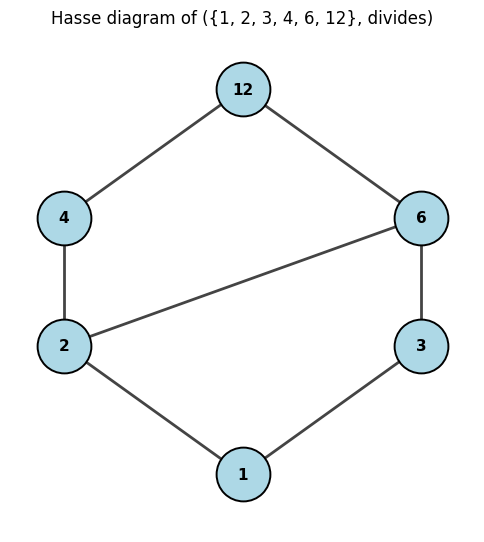

In [ ]:
S1 = [1, 2, 3, 4, 6, 12]
divides = lambda a, b: b % a == 0

all_pairs = [(a, b) for a in S1 for b in S1 if a != b and divides(a, b)]
covers1 = cover_relations(S1, divides)
print("Strict relation pairs (a | b, a ≠ b):", len(all_pairs), all_pairs)
print("Covering pairs (Hasse edges)         :", len(covers1), sorted(covers1))
print("Partial order check (reflexive, antisymmetric, transitive):", check_partial_order(S1, divides))

fig, ax = plt.subplots(figsize=(6, 6.5))
draw_hasse(ax, S1, divides, color='lightblue', title='Hasse diagram of ({1, 2, 3, 4, 6, 12}, divides)')
plt.show()

# **Example 2: Subsets of a set**

Consider $S=\{a,b,c\}$ and the power set $\mathcal P(S)$ ordered by inclusion: $A\preceq B$ if $A\subseteq B$. This gives the familiar cube-shaped Hasse diagram of the Boolean lattice $B_3$ with 8 elements and 12 covering pairs.

Number of elements: 8    covering pairs: 12
Partial order check: (True, True, True)


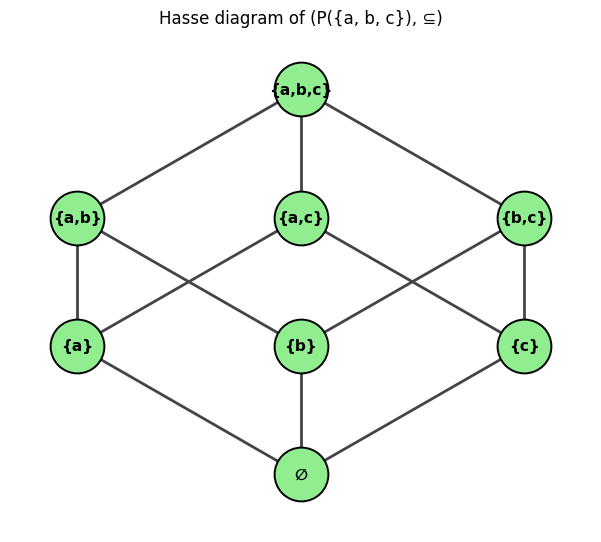

In [ ]:
def set_label(s):
    return '∅' if not s else '{' + ','.join(sorted(s)) + '}'

S2 = [frozenset(c) for k in range(4) for c in itertools.combinations('abc', k)]
subset = lambda A, B: A <= B

covers2 = cover_relations(S2, subset)
print("Number of elements:", len(S2), "   covering pairs:", len(covers2))
print("Partial order check:", check_partial_order(S2, subset))

fig, ax = plt.subplots(figsize=(7.5, 6.5))
draw_hasse(ax, S2, subset, label=set_label, color='lightgreen', title='Hasse diagram of (P({a, b, c}), ⊆)')
plt.show()

# **Example 3: A tree as a poset**

The tree with parent–child pairs $(1,2),(1,3),(2,4),(2,5),(3,6),(3,7)$, ordered by *descent*: $a\preceq b$ if $a$ is $b$ itself or a descendant of $b$. The root 1 is the greatest element and the leaves 4, 5, 6, 7 are the minimal elements. The Hasse diagram reproduces the tree exactly.

Covering pairs (child, parent): [(2, 1), (3, 1), (4, 2), (5, 2), (6, 3), (7, 3)]


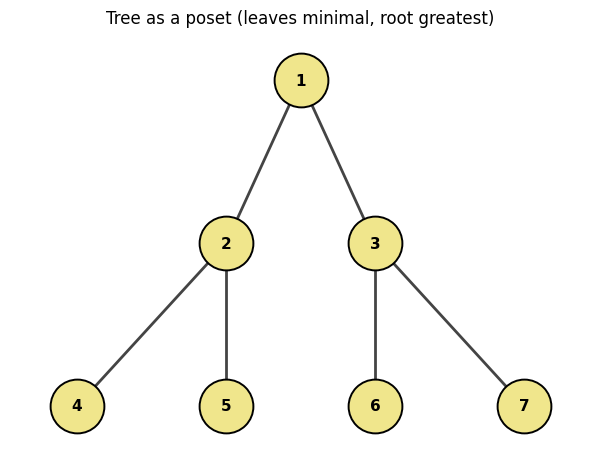

In [ ]:
parent = {2: 1, 3: 1, 4: 2, 5: 2, 6: 3, 7: 3}

def ancestors_or_self(v):
    chain = [v]
    while v in parent:
        v = parent[v]
        chain.append(v)
    return chain

S3 = [4, 5, 6, 7, 2, 3, 1]                                  # leaves first, root last
descendant_of = lambda a, b: b in ancestors_or_self(a)

covers3 = cover_relations(S3, descendant_of)
print("Covering pairs (child, parent):", sorted(covers3))

fig, ax = plt.subplots(figsize=(7.5, 5.5))
draw_hasse(ax, S3, descendant_of, color='khaki', title='Tree as a poset (leaves minimal, root greatest)')
plt.show()

# **Properties of the three posets**

In [ ]:
reports = [poset_report("Divisibility on {1,2,3,4,6,12}", S1, divides),
           poset_report("Subsets of {a,b,c}", S2, subset, label=set_label),
           poset_report("Tree ordered by descent", S3, descendant_of)]
table = pd.DataFrame(reports).set_index("Poset")
display(table[["|S|", "partial order?", "covering pairs", "minimal", "maximal", "least", "greatest", "height", "width", "lattice?"]])

,|S|,partial order?,covering pairs,minimal,maximal,least,greatest,height,width,lattice?
Poset,,,,,,,,,,
"Divisibility on {1,2,3,4,6,12}",6,True,7,[1],[12],[1],[12],4,2,True
"Subsets of {a,b,c}",8,True,12,[∅],"[{a,b,c}]",[∅],"[{a,b,c}]",4,3,True
Tree ordered by descent,7,True,6,"[4, 5, 6, 7]",[1],none,[1],3,4,False


# **Lattices: joins and meets**

In the divisibility poset the *least upper bound* of $a,b$ is $\operatorname{lcm}(a,b)$ and the *greatest lower bound* is $\gcd(a,b)$; in the subset poset they are $A\cup B$ and $A\cap B$. Divisors of 30 form a lattice that is *isomorphic* to the Boolean lattice $B_3$ — the Hasse diagrams have the same shape.

lcm(a,b) and gcd(a,b) stay inside {1,2,3,4,6,12} for all pairs: True
  e.g. join(4, 6) = lcm(4, 6) = 12     meet(4, 6) = gcd(4, 6) = 2
  e.g. join({a}, {b}) = {a,b}     meet({a,b}, {b,c}) = {b}

Hasse diagram of the divisors of 30 isomorphic to that of the subsets of {a,b,c}? True


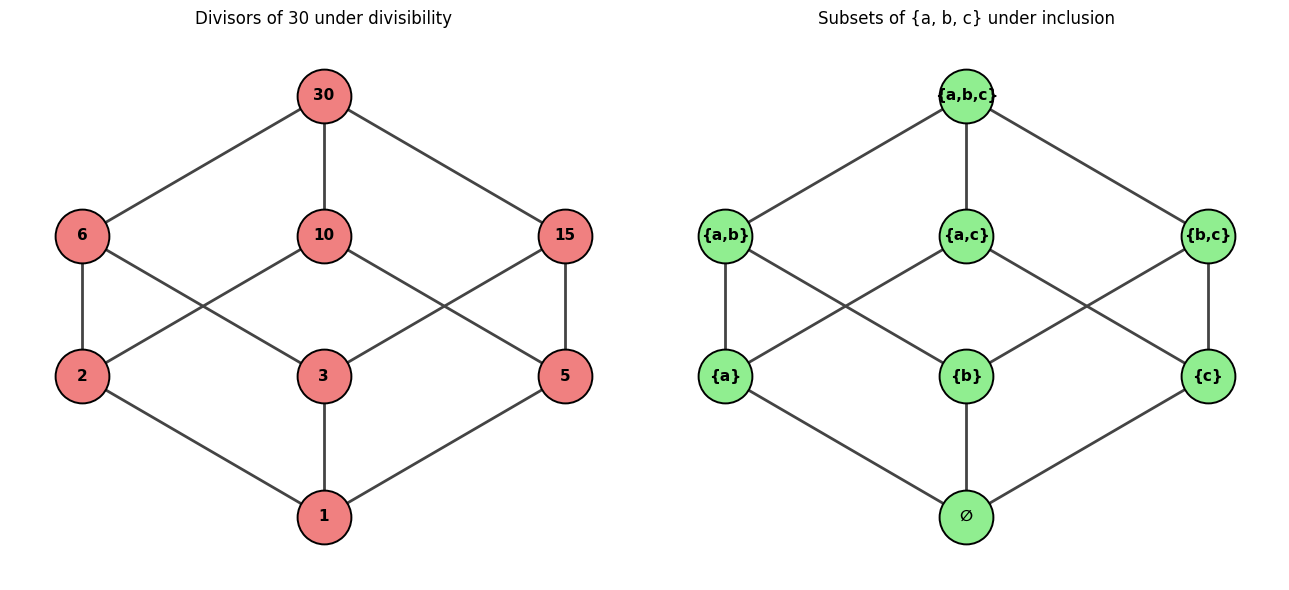

In [ ]:
from math import lcm

# join = lcm and meet = gcd in the divisibility poset
ok = all(lcm(a, b) in S1 and gcd(a, b) in S1 for a in S1 for b in S1)
print("lcm(a,b) and gcd(a,b) stay inside {1,2,3,4,6,12} for all pairs:", ok)
print("  e.g. join(4, 6) = lcm(4, 6) =", lcm(4, 6), "    meet(4, 6) = gcd(4, 6) =", gcd(4, 6))
print("  e.g. join({a}, {b}) =", set_label(frozenset('a') | frozenset('b')), "    meet({a,b}, {b,c}) =", set_label(frozenset('ab') & frozenset('bc')))

D30 = [1, 2, 3, 5, 6, 10, 15, 30]
G30 = nx.DiGraph(cover_relations(D30, divides))
GB3 = nx.DiGraph(covers2)
print("\nHasse diagram of the divisors of 30 isomorphic to that of the subsets of {a,b,c}?", nx.is_isomorphic(G30, GB3))

fig, ax = plt.subplots(1, 2, figsize=(13, 6))
draw_hasse(ax[0], D30, divides, color='lightcoral', title='Divisors of 30 under divisibility')
draw_hasse(ax[1], S2, subset, label=set_label, color='lightgreen', title='Subsets of {a, b, c} under inclusion')
plt.tight_layout()
plt.show()

# **A relation that is not a partial order**

The relation "$<$" on $\{1,2,3\}$ is not reflexive, and "$\mid$" restricted to the set $\{-2,-1,1,2\}$ fails antisymmetry ($1\mid-1$ and $-1\mid1$ but $1\ne-1$); so neither is a partial order and neither has a Hasse diagram.

In [ ]:
print("'<' on {1,2,3}       (reflexive, antisymmetric, transitive):", check_partial_order([1, 2, 3], lambda a, b: a < b))
print("'divides' on {-2,-1,1,2}                                   :", check_partial_order([-2, -1, 1, 2], lambda a, b: b % a == 0))
print("'divides' on {1,2,3,4,6,12}                                :", check_partial_order(S1, divides))

'<' on {1,2,3}       (reflexive, antisymmetric, transitive): (False, True, True)
'divides' on {-2,-1,1,2}                                   : (True, False, True)
'divides' on {1,2,3,4,6,12}                                : (True, True, True)


# **Result**

The Hasse diagrams of the divisibility poset $(\{1,2,3,4,6,12\},\mid)$, of the power set of $\{a,b,c\}$ under inclusion, and of a 7-node tree were drawn from the *cover relations*: 7, 12 and 6 edges respectively (instead of the 12, 19 and 10 pairs of the full strict relation). The special elements were found: the divisibility poset has least element 1, greatest element 12 and width 2; the subset poset has least element $\emptyset$, greatest element $\{a,b,c\}$ and width 3; the tree has greatest element 1 and four minimal elements. The first two posets are lattices (join = lcm / union, meet = gcd / intersection), and the divisors of 30 form a lattice isomorphic to $B_3$.

# **Discussion**

A Hasse diagram removes information that can be recovered: loops follow from reflexivity and edges $a\to c$ follow from $a\to b\to c$ by transitivity, so only the covering pairs need to be drawn, and the upward direction replaces arrows. Placing every element one level above the highest element it covers makes chains read from bottom to top and antichains appear as elements of the same level. The earlier practice of drawing *all* pairs $a\mid b$ (as in a plain directed graph) produces a cluttered picture; the transitive reduction gives the unique minimal diagram. The isomorphism $D_{30}\cong B_3$ reflects that $30=2\cdot3\cdot5$ has three distinct prime factors — each divisor corresponds to a subset of $\{2,3,5\}$.

# **Practice Problems**

**Problem 1.** Draw the Hasse diagram of the divisors of 36 under divisibility. Find its minimal, maximal, least and greatest elements and its width. Is it a lattice?

**Problem 2.** Draw the Hasse diagram of $(\{1,2,3,4,5,6,7,8\},\mid)$. Find all maximal elements and a longest chain.

**Problem 3.** Let $S=\{2,3,4,6,8,12,24\}$ with the divisibility order. Draw the Hasse diagram, find the least upper bound and greatest lower bound of $\{4,6\}$ and of $\{8,12\}$, and decide whether $S$ is a lattice.

**Problem 4.** Show with `check_partial_order` that "is a subset of" on the power set of $\{1,2,3,4\}$ is a partial order and draw its Hasse diagram (16 elements, 32 covering pairs).

---

# **EXPERIMENT 6**

---

# **Plotting Different Types of Directed and Undirected Graphs with Proper Labelling**

# **Aim:**

To construct and visualise different types of directed and undirected graphs using Python (NetworkX and Matplotlib), and to label their nodes and edges for clear representation.

# **Software required:**

Python 3, NetworkX, Matplotlib, Pandas

# **Objectives:**

* To understand the structure of, and the difference between, directed and undirected graphs.
* To use NetworkX for creating graphs and Matplotlib for visualisation.
* To apply proper labelling and styling for clarity in graphical representation.
* To compare simple and complex graph structures using different layouts and visual features.

# **Theory:**

A **graph** $G=(V,E)$ consists of a set of vertices (nodes) $V$ and a set of edges $E$.

* In an **undirected graph** an edge $\{u,v\}$ has no direction; the **degree** of a vertex is the number of edges at it, and $\sum\deg(v)=2|E|$ (handshaking lemma).
* In a **directed graph (digraph)** an edge $(u,v)$ points from $u$ to $v$; each vertex has an **in-degree** and an **out-degree**, and $\sum\text{in-deg}=\sum\text{out-deg}=|E|$.
* A **weighted graph** attaches a number (weight) to every edge.
* A graph is **connected** if there is a path between every pair of vertices; a digraph is *strongly connected* if every vertex can reach every other vertex by directed paths and *weakly connected* if the underlying undirected graph is connected.
* Special graphs: complete graph $K_n$ (all pairs adjacent, $\binom n2$ edges), cycle $C_n$, path $P_n$, star, wheel, complete bipartite graph $K_{m,n}$.

# **Algorithm for plotting a directed graph:**

1. Import `networkx` and `matplotlib.pyplot`.
2. Create a directed graph object `DG = nx.DiGraph()`.
3. Add nodes and directed edges with `DG.add_edges_from()` using ordered pairs.
4. Choose a layout for positioning, e.g. `pos = nx.spring_layout(DG, seed=1)`.
5. Draw the graph with `nx.draw()` using `with_labels=True`, `arrows=True` and styling options (`node_size`, `node_color`, `font_size`).
6. Set the title with `plt.title()` and display with `plt.show()`.

# **Algorithm for plotting an undirected graph:**

1. Import the libraries.
2. Create an undirected graph object `UG = nx.Graph()`.
3. Add nodes and undirected edges with `UG.add_edges_from()`.
4. Choose a layout for positioning.
5. Draw with `nx.draw()` with `with_labels=True` and node/font styling (no arrows are needed).
6. Add a title and display.

# **6.1 A directed graph**

The directed 5-cycle $1\to2\to3\to4\to5\to1$. `nx.DiGraph()` creates a directed graph, `add_edges_from()` adds the edges (the order within each pair gives the direction) and `arrows=True` draws the arrow heads. The circular layout places the vertices on a circle.

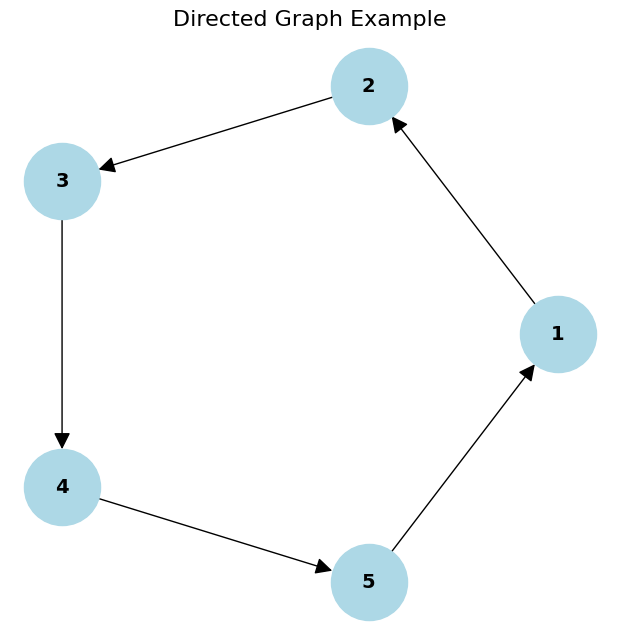

Edges: [(1, 2), (2, 3), (3, 4), (4, 5), (5, 1)]
In-degrees : {1: 1, 2: 1, 3: 1, 4: 1, 5: 1}
Out-degrees: {1: 1, 2: 1, 3: 1, 4: 1, 5: 1}
Strongly connected? True


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

# Creating a directed graph
DG = nx.DiGraph()
DG.add_edges_from([(1, 2), (2, 3), (3, 4), (4, 5), (5, 1)])

plt.figure(figsize=(6, 6))
nx.draw(DG, nx.circular_layout(DG), with_labels=True, node_size=3000, node_color='lightblue',
        font_size=14, font_weight='bold', arrows=True, arrowsize=25)
plt.title('Directed Graph Example', fontsize=16)
plt.show()

print("Edges:", list(DG.edges()))
print("In-degrees :", dict(DG.in_degree()))
print("Out-degrees:", dict(DG.out_degree()))
print("Strongly connected?", nx.is_strongly_connected(DG))

# **6.2 An undirected graph**

The same vertices and edges as an undirected graph: the order of the nodes in each pair no longer matters and the edges are drawn as plain lines.

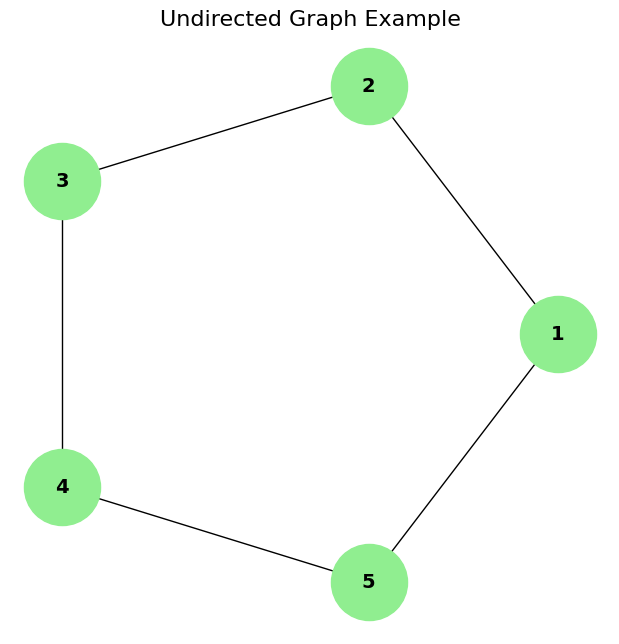

Edges  : [(1, 2), (1, 5), (2, 3), (3, 4), (4, 5)]
Degrees: {1: 2, 2: 2, 3: 2, 4: 2, 5: 2}   sum of degrees = 10 = 2|E| = 10
Connected? True


In [ ]:
# Creating an undirected graph
UG = nx.Graph()
UG.add_edges_from([(1, 2), (2, 3), (3, 4), (4, 5), (5, 1)])

plt.figure(figsize=(6, 6))
nx.draw(UG, nx.circular_layout(UG), with_labels=True, node_size=3000, node_color='lightgreen',
        font_size=14, font_weight='bold')
plt.title('Undirected Graph Example', fontsize=16)
plt.show()

print("Edges  :", list(UG.edges()))
print("Degrees:", dict(UG.degree()), "  sum of degrees =", sum(d for _, d in UG.degree()), "= 2|E| =", 2 * UG.number_of_edges())
print("Connected?", nx.is_connected(UG))

# **6.3 Directed and undirected graphs with a more complex structure**

A directed and an undirected graph are plotted side by side for comparison. The directed graph has edges $(1,2),(2,3),(3,4),(4,5),(2,5),(1,4)$; the undirected graph has the same edges and one more, $\{3,5\}$. `plt.subplot(1, 2, k)` (or `plt.subplots`) creates the two-panel layout.

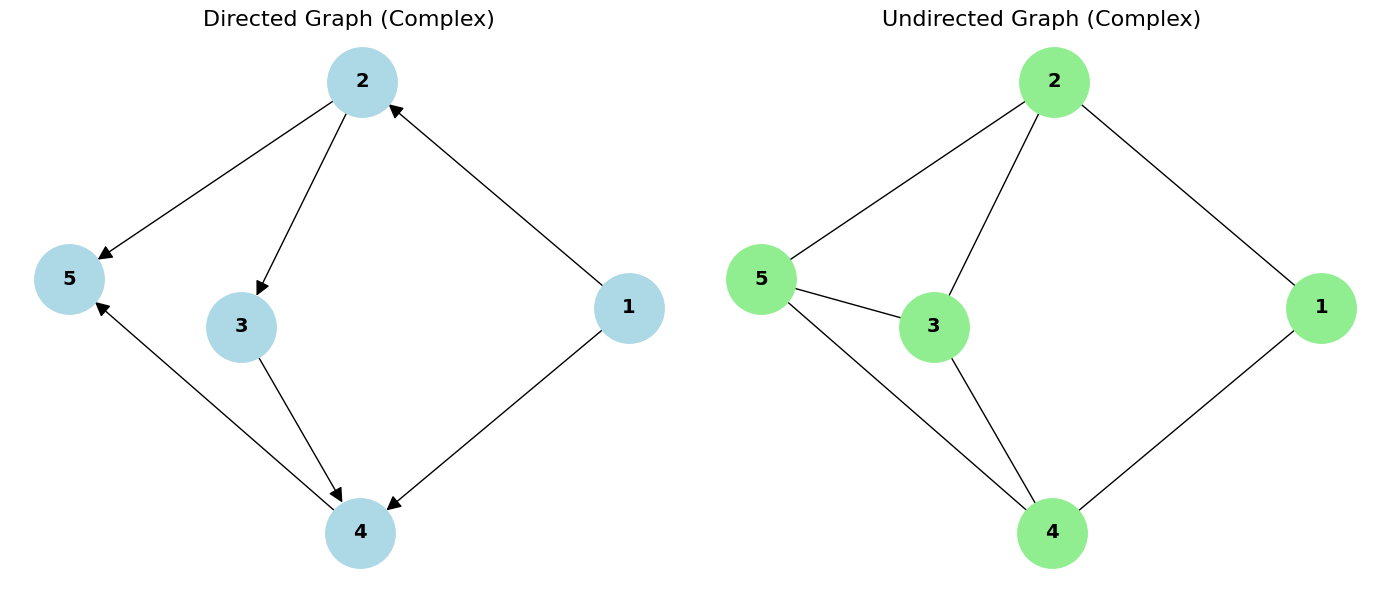

Directed graph  : edges = 6 | weakly connected: True | strongly connected: False | acyclic (a DAG): True
  in-degrees : {1: 0, 2: 1, 3: 1, 4: 2, 5: 2}   out-degrees: {1: 2, 2: 2, 3: 1, 4: 1, 5: 0}
Undirected graph: edges = 7 | connected: True | bipartite: False
  degrees    : {1: 2, 2: 3, 3: 3, 4: 3, 5: 3}   triangles: 2


In [ ]:
DG_complex = nx.DiGraph()
DG_complex.add_edges_from([(1, 2), (2, 3), (3, 4), (4, 5), (2, 5), (1, 4)])

UG_complex = nx.Graph()
UG_complex.add_edges_from([(1, 2), (2, 3), (3, 4), (4, 5), (2, 5), (1, 4), (3, 5)])

pos = nx.spring_layout(UG_complex, seed=3)

fig, ax = plt.subplots(1, 2, figsize=(14, 6))
nx.draw(DG_complex, pos, with_labels=True, node_size=2500, node_color='lightblue', font_size=14, font_weight='bold',
        arrows=True, arrowsize=22, ax=ax[0])
ax[0].set_title('Directed Graph (Complex)', fontsize=16)
nx.draw(UG_complex, pos, with_labels=True, node_size=2500, node_color='lightgreen', font_size=14, font_weight='bold', ax=ax[1])
ax[1].set_title('Undirected Graph (Complex)', fontsize=16)
plt.tight_layout()
plt.show()

print("Directed graph  : edges =", DG_complex.number_of_edges(), "| weakly connected:", nx.is_weakly_connected(DG_complex),
      "| strongly connected:", nx.is_strongly_connected(DG_complex), "| acyclic (a DAG):", nx.is_directed_acyclic_graph(DG_complex))
print("  in-degrees :", dict(DG_complex.in_degree()), "  out-degrees:", dict(DG_complex.out_degree()))
print("Undirected graph: edges =", UG_complex.number_of_edges(), "| connected:", nx.is_connected(UG_complex),
      "| bipartite:", nx.is_bipartite(UG_complex))
print("  degrees    :", dict(UG_complex.degree()), "  triangles:", sum(nx.triangles(UG_complex).values()) // 3)

# **6.4 Additional customisations**

The node shape, edge style, colours and layout can all be changed. Below: square nodes with dashed edges, node colour and size according to the degree, and edge labels.

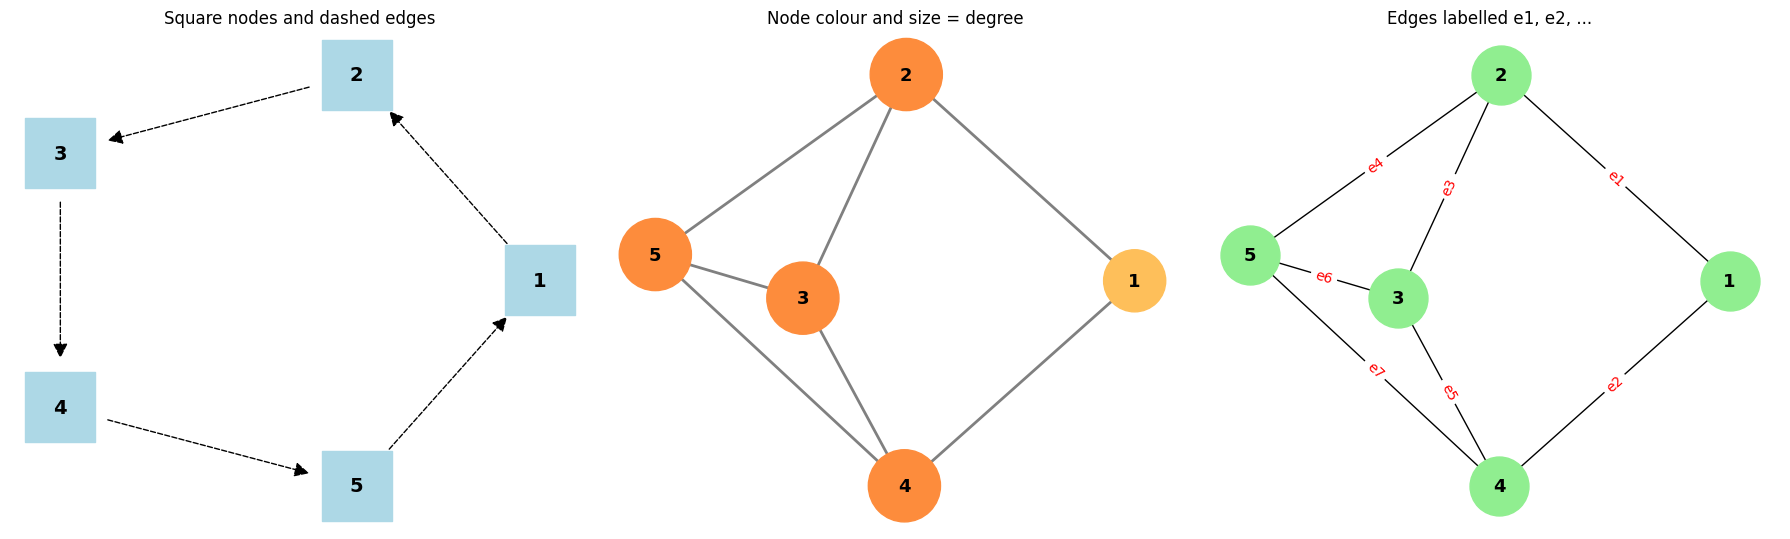

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5.5))

# (a) square nodes, dashed edges
nx.draw(DG, nx.circular_layout(DG), with_labels=True, node_size=2500, node_color='lightblue', font_size=14, font_weight='bold',
        arrows=True, arrowsize=22, node_shape='s', style='dashed', ax=ax[0])
ax[0].set_title('Square nodes and dashed edges')

# (b) node colour and size according to the degree
deg = dict(UG_complex.degree())
nx.draw(UG_complex, pos, with_labels=True, node_size=[600 + 700 * deg[n] for n in UG_complex], node_color=[deg[n] for n in UG_complex],
        cmap=plt.cm.YlOrRd, vmin=0, vmax=6, font_size=13, font_weight='bold', edge_color='gray', width=2, ax=ax[1])
ax[1].set_title('Node colour and size = degree')

# (c) edges labelled with their names
nx.draw(UG_complex, pos, with_labels=True, node_size=1800, node_color='lightgreen', font_size=13, font_weight='bold', ax=ax[2])
nx.draw_networkx_edge_labels(UG_complex, pos, edge_labels={e: f"e{i + 1}" for i, e in enumerate(UG_complex.edges())}, font_color='red', ax=ax[2])
ax[2].set_title('Edges labelled e1, e2, ...')
plt.tight_layout()
plt.show()

# **6.5 Different layouts**

NetworkX supports several layouts for positioning the vertices; the *same* graph looks different in each. The layouts are compared for the undirected graph of Section 6.3.

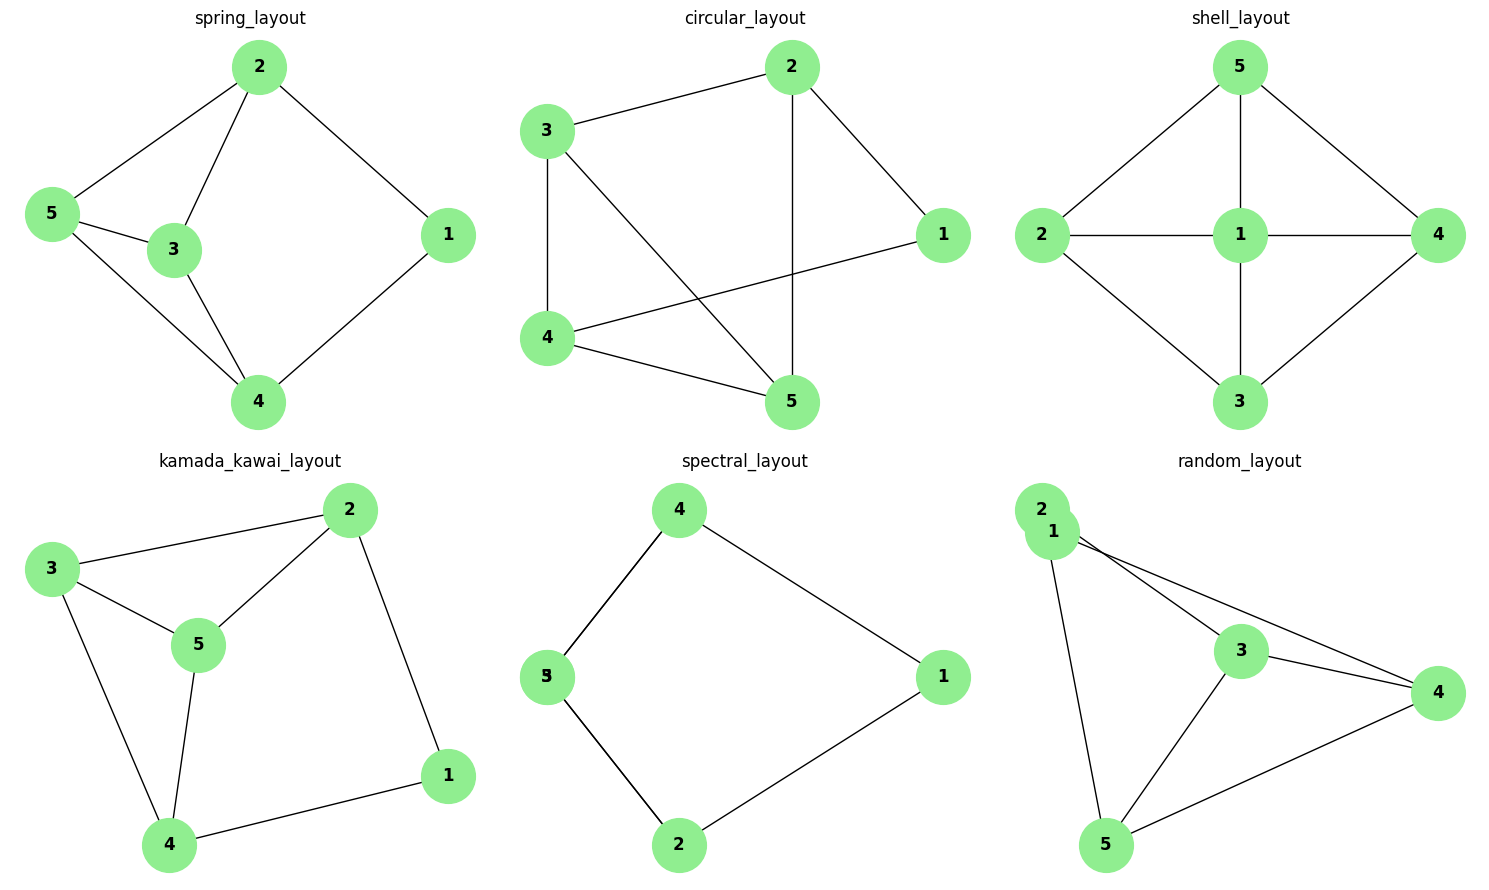

In [ ]:
layouts = {
    "spring_layout":        nx.spring_layout(UG_complex, seed=3),
    "circular_layout":      nx.circular_layout(UG_complex),
    "shell_layout":         nx.shell_layout(UG_complex, nlist=[[1], [2, 3, 4, 5]]),
    "kamada_kawai_layout":  nx.kamada_kawai_layout(UG_complex),
    "spectral_layout":      nx.spectral_layout(UG_complex),
    "random_layout":        nx.random_layout(UG_complex, seed=5),
}
fig, ax = plt.subplots(2, 3, figsize=(15, 9))
for a, (name, p_) in zip(ax.ravel(), layouts.items()):
    nx.draw(UG_complex, p_, with_labels=True, node_size=1500, node_color='lightgreen', font_size=12, font_weight='bold', ax=a)
    a.set_title(name)
plt.tight_layout()
plt.show()

# **6.6 A weighted graph with labelled edges**

For a weighted graph the weights are stored as an edge attribute `weight`, printed on the edges with `draw_networkx_edge_labels`, and used here also to set the **thickness** of each edge.

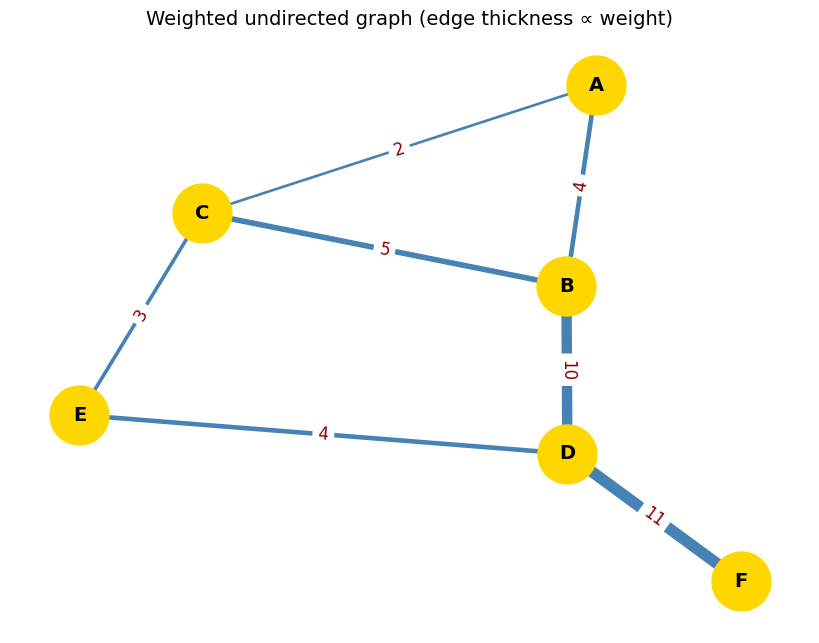

Total weight of all edges: 39    weighted degrees: {'A': 6, 'B': 19, 'C': 10, 'D': 25, 'E': 7, 'F': 11}


In [ ]:
W = nx.Graph()
W.add_weighted_edges_from([('A', 'B', 4), ('A', 'C', 2), ('B', 'C', 5), ('B', 'D', 10), ('C', 'E', 3), ('D', 'E', 4), ('D', 'F', 11)])
posW = nx.spring_layout(W, seed=7)
weights = nx.get_edge_attributes(W, 'weight')

plt.figure(figsize=(8, 6))
nx.draw(W, posW, with_labels=True, node_size=1800, node_color='gold', font_size=14, font_weight='bold',
        width=[0.5 + 0.7 * w for w in weights.values()], edge_color='steelblue')
nx.draw_networkx_edge_labels(W, posW, edge_labels=weights, font_size=12, font_color='darkred')
plt.title('Weighted undirected graph (edge thickness ∝ weight)', fontsize=14)
plt.show()
print("Total weight of all edges:", sum(weights.values()), "   weighted degrees:", dict(W.degree(weight='weight')))

# **6.7 Gallery of special graphs**

Six standard families of graphs with their numbers of vertices and edges and their degree sequences; compare with the formulae $|E(K_n)|=\binom n2$, $|E(C_n)|=|E(P_n)|+1=n$, $|E(K_{m,n})|=mn$ and $|E(W_n)|=2(n-1)$ (wheel with $n$ vertices).

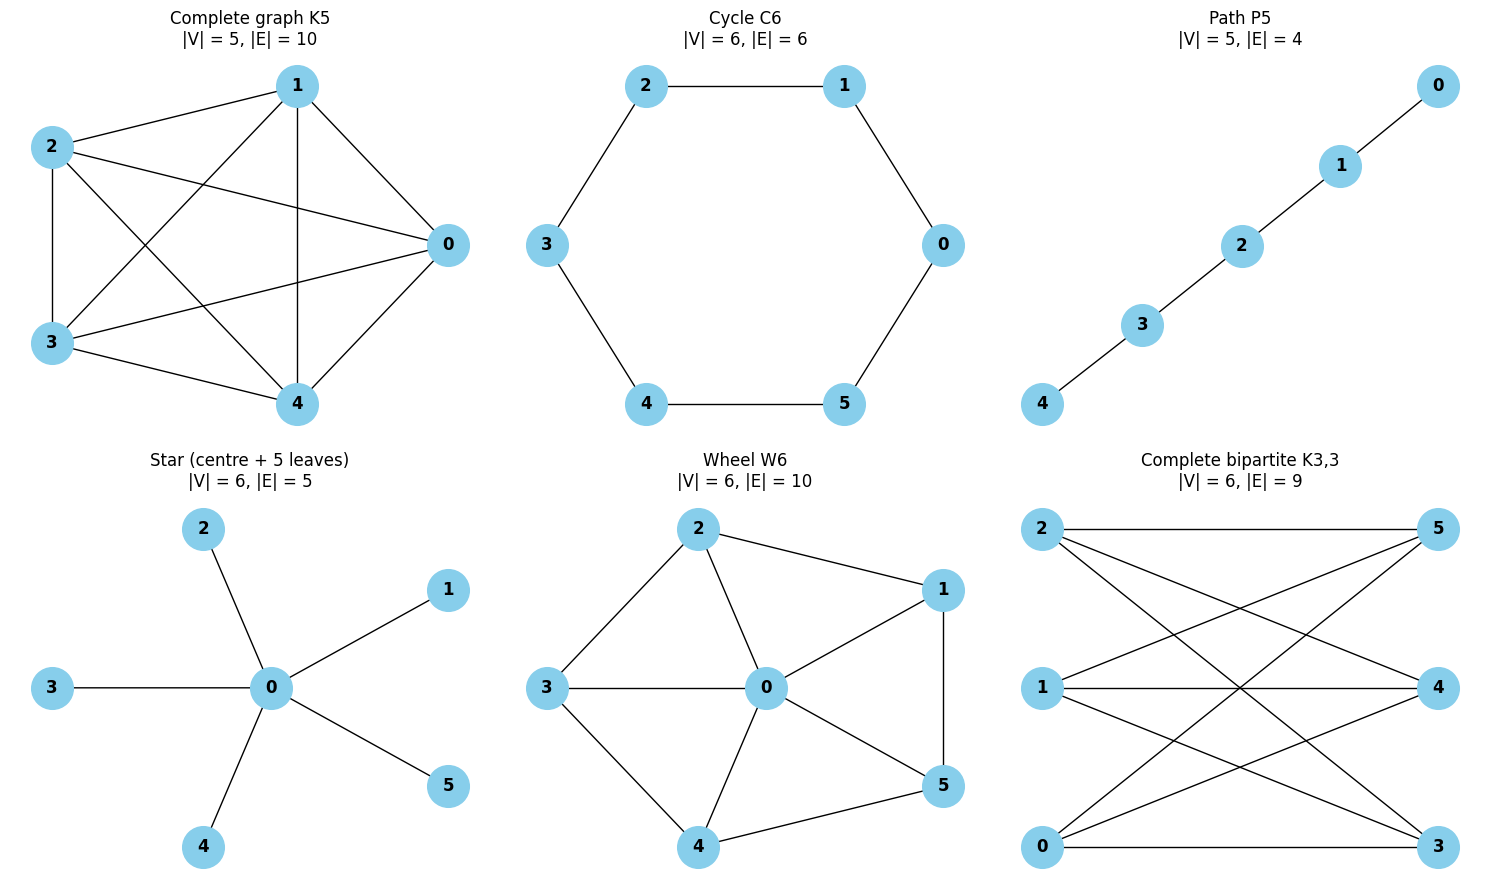

,|V|,|E|,degree sequence,connected
Graph,,,,
Complete graph K5,5,10,"[4, 4, 4, 4, 4]",True
Cycle C6,6,6,"[2, 2, 2, 2, 2, 2]",True
Path P5,5,4,"[2, 2, 2, 1, 1]",True
Star (centre + 5 leaves),6,5,"[5, 1, 1, 1, 1, 1]",True
Wheel W6,6,10,"[5, 3, 3, 3, 3, 3]",True
"Complete bipartite K3,3",6,9,"[3, 3, 3, 3, 3, 3]",True


In [ ]:
gallery = {
    "Complete graph K5":        nx.complete_graph(5),
    "Cycle C6":                 nx.cycle_graph(6),
    "Path P5":                  nx.path_graph(5),
    "Star (centre + 5 leaves)": nx.star_graph(5),
    "Wheel W6":                 nx.wheel_graph(6),
    "Complete bipartite K3,3":  nx.complete_bipartite_graph(3, 3),
}
fig, ax = plt.subplots(2, 3, figsize=(15, 9))
rows = []
for a, (name, g) in zip(ax.ravel(), gallery.items()):
    p_ = nx.bipartite_layout(g, nodes=[0, 1, 2]) if 'bipartite' in name else nx.kamada_kawai_layout(g)
    nx.draw(g, p_, with_labels=True, node_size=900, node_color='skyblue', font_size=12, font_weight='bold', ax=a)
    a.set_title(f"{name}\n|V| = {g.number_of_nodes()}, |E| = {g.number_of_edges()}")
    rows.append({"Graph": name, "|V|": g.number_of_nodes(), "|E|": g.number_of_edges(),
                 "degree sequence": sorted((d for _, d in g.degree()), reverse=True), "connected": nx.is_connected(g)})
plt.tight_layout()
plt.show()
display(pd.DataFrame(rows).set_index("Graph"))

# **Result**

Directed and undirected graphs were created with NetworkX and plotted with Matplotlib with node labels, edge labels, weights, colours, shapes, edge styles and six different layouts. The 5-cycle is strongly connected as a digraph and connected as an undirected graph; the complex directed graph is weakly but not strongly connected (it is acyclic); and the handshaking lemma $\sum\deg(v)=2|E|$ was verified. The special graphs $K_5$, $C_6$, $P_5$, the star, $W_6$ and $K_{3,3}$ have $10,6,4,5,10$ and $9$ edges, in agreement with the formulae.

# **Discussion**

The *same* graph can look very different under different layouts; the layout is only a drawing aid and does not change the graph. Directed graphs need arrows, and two parallel but opposite arrows, $(u,v)$ and $(v,u)$, are different edges, while in an undirected graph they would be the same edge. Weights, labels, colours and sizes allow additional information (degree, cost, class) to be shown on the picture — here the thickness of an edge shows its weight and the size and colour of a vertex its degree. Fixing the `seed` of a layout makes the picture reproducible.

# **Practice Problems**

**Problem 1.** Draw the directed graph with vertices $\{1,\dots,6\}$ and edges $(1,2),(1,3),(2,4),(3,4),(4,5),(5,6),(6,4)$ in a layout of your choice. Find the in-degree and out-degree of each vertex and decide whether it is strongly connected; which vertices lie on a directed cycle?

**Problem 2.** Plot the complete graph $K_6$ and the complete bipartite graph $K_{2,4}$. Verify the number of edges and that $\sum\deg(v)=2|E|$ for both.

**Problem 3.** Plot a weighted graph of 6 cities of your choice with distances on the edges, show the weights on the edges, make the thickness proportional to the weight, and highlight the shortest edge in red.

**Problem 4.** Draw the Petersen graph with `nx.petersen_graph()` (use a circular and a shell layout) and find its number of vertices, edges, degrees and whether it is bipartite.

---

# **EXPERIMENT 7**

---

# **Matrix Representation of Graphs**

# **Aim:**

To understand and implement the matrix representation of graphs — the **adjacency matrix** and the **incidence matrix** — using Python, and to analyse the relationships between vertices and edges from these matrices.

# **Software required:**

Python 3, NumPy, Matplotlib

# **Theory:**

A graph is a collection of vertices (nodes) and edges (connections between nodes).

**Adjacency matrix $A$** ($n\times n$, $n$ = number of vertices)

* Rows and columns represent the vertices.
* $a_{ij}=1$ if there is an edge between vertex $i$ and vertex $j$, otherwise $0$. For an undirected graph $A$ is symmetric. For a weighted graph $a_{ij}$ is the weight of the edge. For a directed graph $a_{ij}$ refers to the edge $i\to j$.
* Row sum $=$ (out-)degree of a vertex; column sum $=$ in-degree.
* **Powers of $A$:** $(A^k)_{ij}$ is the number of walks of length $k$ from $i$ to $j$.

**Incidence matrix $B$** ($n\times m$, $m$ = number of edges)

* Rows represent vertices and columns represent edges.
* *Undirected graph:* $b_{ij}=1$ if vertex $i$ is an end-point of edge $j$, else $0$ — every column has exactly two 1s.
* *Directed graph:* $b_{ij}=-1$ if edge $j$ leaves vertex $i$ and $+1$ if it enters vertex $i$ (for a *weighted* digraph the entries are $-w$ and $+w$) — every column sums to 0.

# **Procedure:**

1. Define a graph using vertices and edges.
2. Represent the graph using an adjacency matrix.
3. Represent the graph using an incidence matrix.
4. Write a Python program to generate and display both matrices.
5. Analyse the results to verify the graph's connectivity (degrees, matrix powers, reachability, shortest paths).

# **Example – the cube graph**

The cube graph $Q_3$ has 8 vertices and 12 edges: an outer square $0\!-\!1\!-\!2\!-\!3$, an inner square $4\!-\!5\!-\!6\!-\!7$, joined by four connecting edges $0\!-\!4,1\!-\!5,2\!-\!6,3\!-\!7$.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Cube graph: outer square 0-1-2-3, inner square 4-5-6-7, joined by spokes
n = 8
edges = [
    (0, 1), (1, 2), (2, 3), (3, 0),   # outer square
    (4, 5), (5, 6), (6, 7), (7, 4),   # inner square
    (0, 4), (1, 5), (2, 6), (3, 7),   # connecting edges
]

# Adjacency matrix (n x n)
adj = np.zeros((n, n), dtype=int)
for u, v in edges:
    adj[u, v] = adj[v, u] = 1

# Incidence matrix (n x edges)
inc = np.zeros((n, len(edges)), dtype=int)
for j, (u, v) in enumerate(edges):
    inc[u, j] = inc[v, j] = 1

degree = adj.sum(axis=1)

print("Adjacency Matrix:")
print(adj)
print("\nIncidence Matrix (rows = vertices, cols = edges):")
print(inc)
print("\nDegrees:", degree)
print("Edges:", len(edges))

Adjacency Matrix:
[[0 1 0 1 1 0 0 0]
 [1 0 1 0 0 1 0 0]
 [0 1 0 1 0 0 1 0]
 [1 0 1 0 0 0 0 1]
 [1 0 0 0 0 1 0 1]
 [0 1 0 0 1 0 1 0]
 [0 0 1 0 0 1 0 1]
 [0 0 0 1 1 0 1 0]]

Incidence Matrix (rows = vertices, cols = edges):
[[1 0 0 1 0 0 0 0 1 0 0 0]
 [1 1 0 0 0 0 0 0 0 1 0 0]
 [0 1 1 0 0 0 0 0 0 0 1 0]
 [0 0 1 1 0 0 0 0 0 0 0 1]
 [0 0 0 0 1 0 0 1 1 0 0 0]
 [0 0 0 0 1 1 0 0 0 1 0 0]
 [0 0 0 0 0 1 1 0 0 0 1 0]
 [0 0 0 0 0 0 1 1 0 0 0 1]]

Degrees: [3 3 3 3 3 3 3 3]
Edges: 12


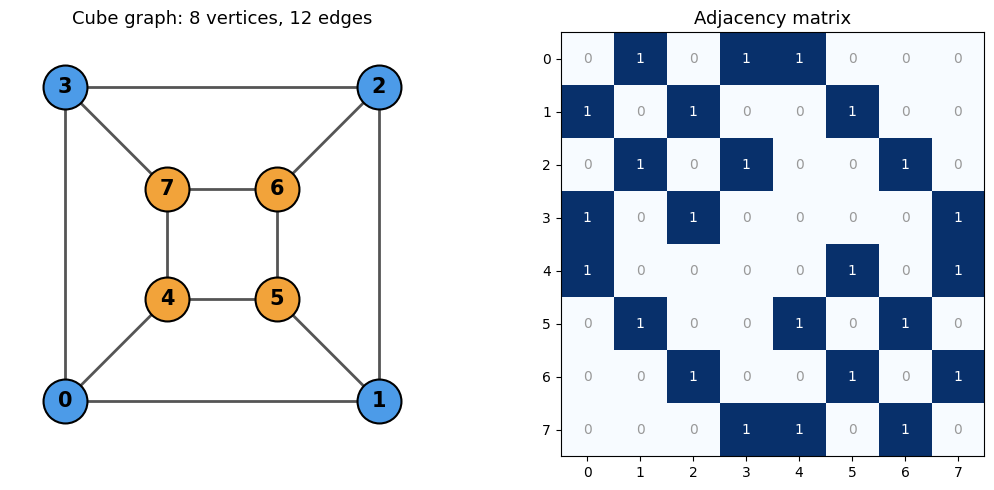

In [ ]:
# Vertex positions
pos = {0: (0, 0), 1: (4, 0), 2: (4, 4), 3: (0, 4), 4: (1.3, 1.3), 5: (2.7, 1.3), 6: (2.7, 2.7), 7: (1.3, 2.7)}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))

# Left: the graph
for u, v in edges:
    ax1.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]], color="#555", lw=2, zorder=1)
for node, (x, y) in pos.items():
    color = "#4C9BE8" if node < 4 else "#F2A33A"
    ax1.scatter(x, y, s=1000, color=color, edgecolors="k", linewidths=1.5, zorder=2)
    ax1.text(x, y, str(node), ha="center", va="center", fontsize=15, fontweight="bold", zorder=3)
ax1.set_title("Cube graph: 8 vertices, 12 edges", fontsize=13)
ax1.set_xlim(-0.7, 4.7); ax1.set_ylim(-0.7, 4.7); ax1.set_aspect("equal"); ax1.axis("off")

# Right: adjacency matrix heat map
ax2.imshow(adj, cmap="Blues")
ax2.set_xticks(range(n)); ax2.set_yticks(range(n))
ax2.set_title("Adjacency matrix", fontsize=13)
for i in range(n):
    for j in range(n):
        ax2.text(j, i, adj[i, j], ha="center", va="center", color="white" if adj[i, j] else "#999")
plt.tight_layout()
plt.show()

**Checking the matrices.** Several properties follow directly from the two matrices:

* the sum of all degrees is $2|E|$; every column of the incidence matrix has two 1s;
* $A$ is symmetric and $B B^{T}=A+D$ ($D$ = diagonal matrix of degrees);
* $(A^2)_{ij}$ counts walks of length 2, and $\operatorname{trace}(A^3)/6$ is the number of triangles;
* the graph is connected when $(I+A)^{n-1}$ has no zero entries.

In [ ]:
D = np.diag(degree)
print("Sum of degrees =", degree.sum(), "  = 2|E| =", 2 * len(edges))
print("Every incidence column has two 1s :", bool((inc.sum(axis=0) == 2).all()))
print("A is symmetric                   :", bool((adj == adj.T).all()))
print("B Bᵀ = A + D                     :", bool((inc @ inc.T == adj + D).all()))

A2 = np.linalg.matrix_power(adj, 2)
print("\n(A²)[0,2] = walks of length 2 from vertex 0 to vertex 2 =", A2[0, 2], "  (via vertex 1 and via vertex 3)")
print("(A²)[0,0] = degree of vertex 0                           =", A2[0, 0])
print("Number of triangles = trace(A³)/6 =", np.trace(np.linalg.matrix_power(adj, 3)) // 6)

reach = np.linalg.matrix_power(np.eye(n, dtype=int) + adj, n - 1) > 0
print("Connected graph? ((I + A)^(n-1) has no zero entry):", bool(reach.all()))
print("Eigenvalues of A:", np.round(np.sort(np.linalg.eigvalsh(adj))[::-1], 4), " -> symmetric about 0 because the cube is bipartite")

Sum of degrees = 24   = 2|E| = 24
Every incidence column has two 1s : True
A is symmetric                   : True
B Bᵀ = A + D                     : True

(A²)[0,2] = walks of length 2 from vertex 0 to vertex 2 = 2   (via vertex 1 and via vertex 3)
(A²)[0,0] = degree of vertex 0                           = 3
Number of triangles = trace(A³)/6 = 0
Connected graph? ((I + A)^(n-1) has no zero entry): True
Eigenvalues of A: [ 3.  1.  1.  1. -1. -1. -1. -3.]  -> symmetric about 0 because the cube is bipartite


# **Observation**

Run the code above to generate the adjacency and incidence matrices; verify the connectivity of the graph by checking the matrices, and check the plot. Every vertex of the cube has degree 3 (a 3-regular graph), so the sum of the degrees is $24=2\cdot12$; each column of the incidence matrix contains exactly two 1s; there are 2 walks of length 2 between the diagonally opposite corners 0 and 2 of the same face and no triangles.

# **Problem Statement**

Represent the following **weighted, directed graph** using both the adjacency matrix and the incidence matrix. Write a Python program to generate both matrices, analyse the graph, and plot it.

**Graph:** vertices $V=\{0,1,2,3\}$ and directed edges

* E1: $0\to1$ (weight 5)
* E2: $1\to2$ (weight 3)
* E3: $2\to3$ (weight 4)
* E4: $0\to2$ (weight 6)
* E5: $1\to3$ (weight 2)

**Tasks**

* **Adjacency matrix:** construct the weighted adjacency matrix, where entry $[u,v]$ is the weight of the edge $u\to v$ (0 if there is no edge). Verify that the weights are correctly assigned for directed edges (for example, $[0,1]=5$ but $[1,0]=0$).
* **Incidence matrix:** construct the incidence matrix with one column per edge (E1 to E5). Use $+w$ for incoming edges and $-w$ for outgoing edges.
* **Analysis:** find the in-degree and out-degree of every vertex; check whether a path from vertex 0 to vertex 3 exists; find the shortest path from vertex 0 to vertex 3 and its cost; find the total weight of all edges.
* **Plot:** draw the directed graph with arrows and edge weights, and highlight the shortest path.

In [ ]:
# Weighted directed graph: (from, to, weight)
n = 4
edges = [(0, 1, 5), (1, 2, 3), (2, 3, 4), (0, 2, 6), (1, 3, 2)]
m = len(edges)

# Adjacency matrix: adj[u, v] = weight of edge u -> v
adj = np.zeros((n, n), dtype=int)
for u, v, w in edges:
    adj[u, v] = w

# Incidence matrix: -w at the source, +w at the target, one column per edge
inc = np.zeros((n, m), dtype=int)
for j, (u, v, w) in enumerate(edges):
    inc[u, j] = -w
    inc[v, j] = w

print("Adjacency Matrix:")
print(adj)
print("\nCheck: adj[0,1] =", adj[0, 1], " but adj[1,0] =", adj[1, 0], " (directed edges are not symmetric)")
print("\nIncidence Matrix (columns = E1..E5):")
print(inc)
print("Every column sums to 0 (-w + w):", bool((inc.sum(axis=0) == 0).all()))

# ---- Analysis ----
connected = adj > 0
print("\nOut-degrees:", connected.sum(axis=1))
print("In-degrees: ", connected.sum(axis=0))
print("Total weight of all edges:", adj.sum())

# Reachability: (I + A)^(n-1) has a non-zero entry [i, j] if j is reachable from i
reach = np.linalg.matrix_power(np.eye(n, dtype=int) + connected.astype(int), n - 1) > 0
print("Path from 0 to 3 exists?", bool(reach[0, 3]))

# Shortest paths (Floyd-Warshall) with path reconstruction
INF = float("inf")
dist = np.where(adj > 0, adj, INF).astype(float)
np.fill_diagonal(dist, 0)
nxt = [[v if adj[u, v] > 0 else None for v in range(n)] for u in range(n)]
for k in range(n):
    for i in range(n):
        for j in range(n):
            if dist[i, k] + dist[k, j] < dist[i, j]:
                dist[i, j] = dist[i, k] + dist[k, j]
                nxt[i][j] = nxt[i][k]

def shortest_path(s, t):
    path = [s]
    while s != t:
        s = nxt[s][t]
        path.append(s)
    return path

path = shortest_path(0, 3)
print("Shortest path 0 -> 3:", " -> ".join(map(str, path)), "| cost =", int(dist[0, 3]))
print("Other paths: 0->2->3 costs", 6 + 4, "; 0->1->2->3 costs", 5 + 3 + 4)

Adjacency Matrix:
[[0 5 6 0]
 [0 0 3 2]
 [0 0 0 4]
 [0 0 0 0]]

Check: adj[0,1] = 5  but adj[1,0] = 0  (directed edges are not symmetric)

Incidence Matrix (columns = E1..E5):
[[-5  0  0 -6  0]
 [ 5 -3  0  0 -2]
 [ 0  3 -4  6  0]
 [ 0  0  4  0  2]]
Every column sums to 0 (-w + w): True

Out-degrees: [2 2 1 0]
In-degrees:  [0 1 2 2]
Total weight of all edges: 20
Path from 0 to 3 exists? True
Shortest path 0 -> 3: 0 -> 1 -> 3 | cost = 7
Other paths: 0->2->3 costs 10 ; 0->1->2->3 costs 12


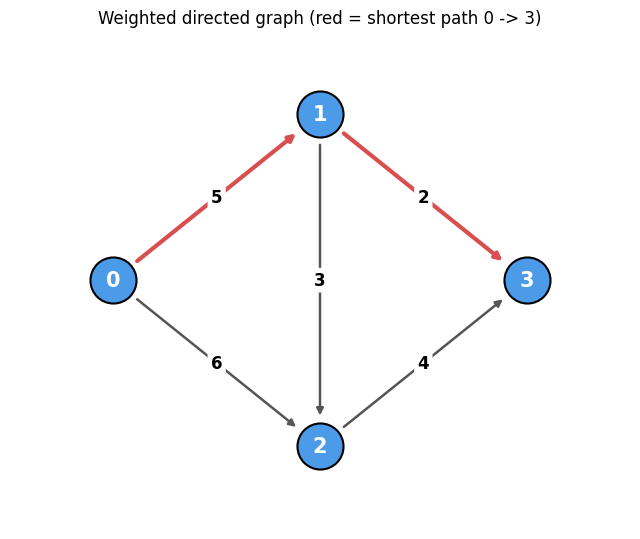

In [ ]:
# ---- Plot ----
pos = {0: (0, 1), 1: (1, 2), 2: (1, 0), 3: (2, 1)}
on_path = set(zip(path, path[1:]))

fig, ax = plt.subplots(figsize=(6.5, 5.5))
for u, v, w in edges:
    highlight = (u, v) in on_path
    ax.annotate("", xy=pos[v], xytext=pos[u],
                arrowprops=dict(arrowstyle="-|>", lw=3 if highlight else 1.8, color="#D94F4F" if highlight else "#555",
                                shrinkA=22, shrinkB=22), zorder=1)
    mx, my = (pos[u][0] + pos[v][0]) / 2, (pos[u][1] + pos[v][1]) / 2
    ax.text(mx, my, str(w), fontsize=12, fontweight="bold", ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none"), zorder=3)
for node, (x, y) in pos.items():
    ax.scatter(x, y, s=1100, color="#4C9BE8", edgecolors="k", linewidths=1.5, zorder=2)
    ax.text(x, y, str(node), ha="center", va="center", fontsize=15, fontweight="bold", color="white", zorder=4)
ax.set_title("Weighted directed graph (red = shortest path 0 -> 3)")
ax.set_xlim(-0.5, 2.5); ax.set_ylim(-0.5, 2.5); ax.axis("off")
plt.tight_layout()
plt.show()

# **Analysis**

* The adjacency matrix shows that vertex 0 has direct edges to vertices 1 (weight 5) and 2 (weight 6) but not directly to vertex 3.
* Vertex 3 can still be reached from vertex 0 through other vertices. The reachability check (matrix powers) confirms that a path $0\to3$ exists.
* The shortest path from 0 to 3 is $0\to1\to3$ with cost $5+2=7$, cheaper than $0\to2\to3$ (cost 10) and $0\to1\to2\to3$ (cost 12).
* The incidence matrix confirms that vertex 0 is part of edges E1 and E4 (both outgoing, so both entries are negative) and vertex 3 is part of edges E3 and E5 (both incoming, so both entries are positive).
* Out-degrees of vertices 0–3 are $[2,2,1,0]$ and in-degrees are $[0,1,2,2]$.
* The total weight of all edges is $5+3+4+6+2=20$.

# **Result**

The adjacency and incidence matrices of the cube graph and of the weighted directed graph were generated and analysed in Python. For the cube: 8 vertices, 12 edges, all degrees 3, no triangles, connected. For the weighted digraph: a path from 0 to 3 exists, the shortest path is $0\to1\to3$ of cost 7, and the total weight is 20.

# **Discussion**

The adjacency matrix is $n\times n$ and gives the neighbours of a vertex in one row — it is the natural form for algorithms such as Floyd–Warshall and for algebraic properties (powers count walks, eigenvalues reveal structure such as bipartiteness). The incidence matrix is $n\times m$ and describes which vertices belong to which edges; for a directed graph its signs record the direction and every column sums to zero, which is the basis of flow-conservation equations (Kirchhoff's laws). For sparse graphs ($m\ll n^2$) both matrices contain mostly zeros, so adjacency *lists* are preferred in practice.

# **Practice Problems**

**Problem 1.** Write the adjacency and incidence matrices of the complete graph $K_4$. Verify that $\sum\deg(v)=2|E|=12$ and that $\operatorname{trace}(A^3)/6=4$ triangles.

**Problem 2.** For the directed graph with edges $0\to1,\;1\to2,\;2\to0,\;2\to3$, find the adjacency matrix, the in- and out-degrees, and use matrix powers to decide whether it is strongly connected.

**Problem 3.** Using $A^k$, find the number of walks of length 3 from vertex 0 to vertex 6 (the opposite corner of the cube). Explain why it is $3!=6$ while the number of walks of length 2 between these vertices is 0.

**Problem 4.** For the weighted digraph of this experiment, add the edge E6: $3\to0$ (weight 1). Recompute the adjacency matrix, decide whether the graph is now strongly connected, and find the cheapest cycle through vertex 0.

---

# **EXPERIMENT 8**

---

# **Implementation of Minimum Spanning Tree Algorithms: Prim's and Kruskal's Algorithms**

# **Aim:**

To understand and implement Prim's and Kruskal's algorithms for finding the Minimum Spanning Tree (MST) of a weighted connected graph, to trace their steps and to compare the results.

# **Software required:**

Python 3, NetworkX, Matplotlib, Pandas, `heapq`

# **Theory:**

**Minimum spanning tree (MST).** A *spanning tree* of a connected graph is a subgraph that contains all the vertices and is a tree (connected, no cycles); it has exactly $n-1$ edges. An MST is a spanning tree of the least possible total edge weight. If all edge weights are distinct the MST is unique.

**Prim's algorithm**

* Starts with an arbitrary vertex.
* Grows the tree by repeatedly adding the **smallest edge that connects a vertex in the tree to a vertex outside it**.
* A greedy approach; with a binary heap the running time is $O(E\log V)$.

**Kruskal's algorithm**

* Starts with all vertices as separate sets (components).
* Considers the edges in **ascending order of weight** and adds an edge only if it **does not form a cycle**.
* Uses the **Union–Find (disjoint-set)** data structure for cycle detection; running time $O(E\log E)$, dominated by sorting.

Both are correct because of the **cut property**: the lightest edge crossing any cut of the graph belongs to some MST.

# **Procedure:**

1. Represent the graph using an adjacency matrix or an edge list.
2. Implement Prim's algorithm:
   * select an arbitrary starting vertex;
   * use a priority queue (min-heap) to find the smallest edge connecting to the tree.
3. Implement Kruskal's algorithm:
   * sort all edges by weight;
   * use Union–Find to ensure that no cycles are formed while adding edges.
4. Compare the results of both algorithms.
5. Observe and analyse the total weight of the MST obtained.

# **The `heapq` module**

The `heapq` module of Python's standard library implements a **heap queue (priority queue)**. Heaps are binary heaps stored as ordinary lists and maintain the *heap property*: the smallest element is always at the root, index 0. A **min-heap** is the default.

**Key features**

* *Min-heap:* the smallest element is always at the top.
* *Efficiency:* insertion and extraction of the smallest element take $O(\log n)$ time.

**Applications:** priority queues (task scheduling), Dijkstra's algorithm (Experiment 9), Prim's algorithm (this experiment) and top-$k$ problems.

**Common functions**

* `heapq.heappush(heap, item)` adds an item while keeping the heap property.
* `heapq.heappop(heap)` removes and returns the smallest element.

In [ ]:
import heapq

heap = []
heapq.heappush(heap, 5)
heapq.heappush(heap, 3)
heapq.heappush(heap, 8)
print("Heap after pushing 5, 3, 8 :", heap)          # the smallest element (3) is at index 0

smallest = heapq.heappop(heap)
print("heappop ->", smallest, "     heap now:", heap)

Heap after pushing 5, 3, 8 : [3, 5, 8]
heappop -> 3      heap now: [5, 8]


* `heapq.heappushpop(heap, item)` pushes a new item and then pops the smallest, in one operation.
* `heapq.heapreplace(heap, item)` pops the smallest element first, *then* pushes the new item (more efficient than pop followed by push).
* `heapq.heapify(list)` converts a list into a heap in place; `heapq.nlargest(n, iterable)` and `heapq.nsmallest(n, iterable)` return the $n$ largest / smallest elements.

In [ ]:
heap = [3, 5, 8]
print("heappushpop(heap, 4) ->", heapq.heappushpop(heap, 4), "    heap now:", heap)

heap = [3, 5, 8]
print("heapreplace(heap, 4) ->", heapq.heapreplace(heap, 4), "    heap now:", heap)

nums = [5, 3, 8, 1]
heapq.heapify(nums)
print("heapify([5, 3, 8, 1]) ->", nums)
print("nlargest(2)  :", heapq.nlargest(2, [5, 3, 8, 1]))
print("nsmallest(2) :", heapq.nsmallest(2, [5, 3, 8, 1]))

# Heap sort: pushing everything and popping repeatedly gives sorted order
data = [7, 2, 9, 4, 1]
h = list(data); heapq.heapify(h)
print("Heap sort of", data, "->", [heapq.heappop(h) for _ in range(len(h))])

heappushpop(heap, 4) -> 3     heap now: [4, 5, 8]
heapreplace(heap, 4) -> 3     heap now: [4, 5, 8]
heapify([5, 3, 8, 1]) -> [1, 3, 8, 5]
nlargest(2)  : [8, 5]
nsmallest(2) : [1, 3]
Heap sort of [7, 2, 9, 4, 1] -> [1, 2, 4, 7, 9]


# **Prim's algorithm**

`prim_mst` follows the steps below. The list `steps` records every step so that the construction can be displayed as a table.

* `n` is the number of vertices; `visited` marks the vertices already in the tree; `mst_edges` stores the edges $(u,v,w)$ of the MST; `total_weight` accumulates the weight.
* The priority queue starts with the tuple `(0, start, -1)` = (weight, vertex, previous vertex).
* The smallest edge is popped; if its vertex is already visited it is skipped (it would form a cycle), otherwise the vertex is added to the tree and the edge to `mst_edges`.
* All edges from the new vertex to unvisited vertices are pushed onto the heap.

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

# ------------------- Prim's Algorithm -------------------
def prim_mst(graph, start=0):
    n = len(graph)                       # Step 1: number of vertices
    visited = [False] * n                # Step 2: vertices already in the tree
    mst_edges = []                       # Step 3: edges of the MST
    total_weight = 0                     # Step 4: total weight of the MST
    steps = []                           # trace of the construction

    min_heap = [(0, start, -1)]          # Step 5: (weight, vertex, previous vertex)
    while min_heap:                      # Step 6: until the heap is empty
        weight, u, prev = heapq.heappop(min_heap)       # Step 7: smallest edge
        if visited[u]:                   # Step 8: would form a cycle -> skip
            continue
        visited[u] = True                # Step 9: add the vertex to the tree
        total_weight += weight
        if prev != -1:
            mst_edges.append((prev, u, weight))
        steps.append({"Step": len(steps) + 1, "Vertex added": u,
                      "Edge used": f"({prev}, {u})" if prev != -1 else "start vertex",
                      "Weight": weight, "Total so far": total_weight})
        for v, w in enumerate(graph[u]):                # Step 10: push edges to unvisited neighbours
            if not visited[v] and w > 0:
                heapq.heappush(min_heap, (w, v, u))
    return mst_edges, total_weight, steps

# **Kruskal's algorithm**

* `DisjointSet` keeps the components: `find(u)` returns the representative of the component of `u` (with *path compression*) and `union(u, v)` merges two components (by *rank*).
* `kruskal_mst` sorts the edges by weight and adds an edge only if its two end-points are in **different** components (`find(u) != find(v)`); otherwise the edge would close a cycle and is rejected.
* The list `steps` records the decision for every edge.

In [ ]:
# ------------------- Kruskal's Algorithm -------------------
class DisjointSet:
    def __init__(self, n):
        self.parent = list(range(n))     # every vertex is its own set
        self.rank = [0] * n              # used for union by rank

    def find(self, u):
        if self.parent[u] != u:          # path compression
            self.parent[u] = self.find(self.parent[u])
        return self.parent[u]

    def union(self, u, v):
        root_u, root_v = self.find(u), self.find(v)
        if root_u != root_v:             # union by rank keeps the trees shallow
            if self.rank[root_u] > self.rank[root_v]:
                self.parent[root_v] = root_u
            elif self.rank[root_u] < self.rank[root_v]:
                self.parent[root_u] = root_v
            else:
                self.parent[root_v] = root_u
                self.rank[root_u] += 1

def kruskal_mst(edges, n):
    ds = DisjointSet(n)                          # Step 1: n separate sets
    mst_edges, total_weight, steps = [], 0, []   # Steps 2-3
    for u, v, weight in sorted(edges, key=lambda e: e[2]):       # Step 4: ascending order of weight
        if ds.find(u) != ds.find(v):             # Step 5: different components -> no cycle
            ds.union(u, v)
            mst_edges.append((u, v, weight))
            total_weight += weight
            decision = "ACCEPT"
        else:
            decision = "reject (forms a cycle)"
        steps.append({"Edge": f"({u}, {v})", "Weight": weight, "Decision": decision, "Total so far": total_weight})
    return mst_edges, total_weight, steps

# ------------------- Visualisation -------------------
def plot_graph_and_mst(ax, graph, mst_edges, title, pos, labels=None):
    G = nx.Graph()
    for i, row in enumerate(graph):
        for j, weight in enumerate(row):
            if weight > 0:
                G.add_edge(i, j, weight=weight)
    mst_set = {frozenset((u, v)) for u, v, _ in mst_edges}
    mst_list = [e for e in G.edges() if frozenset(e) in mst_set]
    other = [e for e in G.edges() if frozenset(e) not in mst_set]
    nx.draw_networkx_edges(G, pos, edgelist=other, edge_color='lightgray', width=1.5, ax=ax)
    nx.draw_networkx_edges(G, pos, edgelist=mst_list, edge_color='red', width=3.5, ax=ax)
    nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=900, edgecolors='k', ax=ax)
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=10, font_weight='bold', ax=ax)
    nx.draw_networkx_edge_labels(G, pos, edge_labels={(u, v): d['weight'] for u, v, d in G.edges(data=True)}, font_size=10, ax=ax)
    ax.set_title(title); ax.axis('off')

# **Example input and execution**

A weighted undirected graph with 5 vertices and 7 edges. It is given as an **adjacency matrix** for Prim's algorithm and as an **edge list** for Kruskal's algorithm (the two describe the same graph).

| Edge | 0–1 | 0–3 | 1–2 | 1–3 | 1–4 | 2–4 | 3–4 |
|---|---|---|---|---|---|---|---|
| Weight | 2 | 6 | 3 | 8 | 5 | 7 | 9 |

In [ ]:
# Adjacency matrix for Prim's algorithm
graph = [
    [0, 2, 0, 6, 0],
    [2, 0, 3, 8, 5],
    [0, 3, 0, 0, 7],
    [6, 8, 0, 0, 9],
    [0, 5, 7, 9, 0],
]
# Edge list for Kruskal's algorithm
edges = [(0, 1, 2), (1, 2, 3), (0, 3, 6), (1, 3, 8), (1, 4, 5), (2, 4, 7), (3, 4, 9)]
n = 5

prim_edges, prim_total, prim_steps = prim_mst(graph)
print("Prim's MST edges   :", prim_edges)
print("Total weight       :", prim_total)
print("\nConstruction of the tree by Prim's algorithm (start vertex 0):")
display(pd.DataFrame(prim_steps).set_index("Step"))

Prim's MST edges   : [(0, 1, 2), (1, 2, 3), (1, 4, 5), (0, 3, 6)]
Total weight       : 16

Construction of the tree by Prim's algorithm (start vertex 0):


,Vertex added,Edge used,Weight,Total so far
Step,,,,
1,0,start vertex,0,0
2,1,"(0, 1)",2,2
3,2,"(1, 2)",3,5
4,4,"(1, 4)",5,10
5,3,"(0, 3)",6,16


In [ ]:
kruskal_edges, kruskal_total, kruskal_steps = kruskal_mst(edges, n)
print("Kruskal's MST edges:", kruskal_edges)
print("Total weight       :", kruskal_total)
print("\nEdges considered by Kruskal's algorithm in increasing order of weight:")
display(pd.DataFrame(kruskal_steps).rename_axis("No.").set_index(pd.RangeIndex(1, len(kruskal_steps) + 1, name="No.")))

Kruskal's MST edges: [(0, 1, 2), (1, 2, 3), (1, 4, 5), (0, 3, 6)]
Total weight       : 16

Edges considered by Kruskal's algorithm in increasing order of weight:


,Edge,Weight,Decision,Total so far
No.,,,,
1,"(0, 1)",2,ACCEPT,2
2,"(1, 2)",3,ACCEPT,5
3,"(1, 4)",5,ACCEPT,10
4,"(0, 3)",6,ACCEPT,16
5,"(2, 4)",7,reject (forms a cycle),16
6,"(1, 3)",8,reject (forms a cycle),16
7,"(3, 4)",9,reject (forms a cycle),16


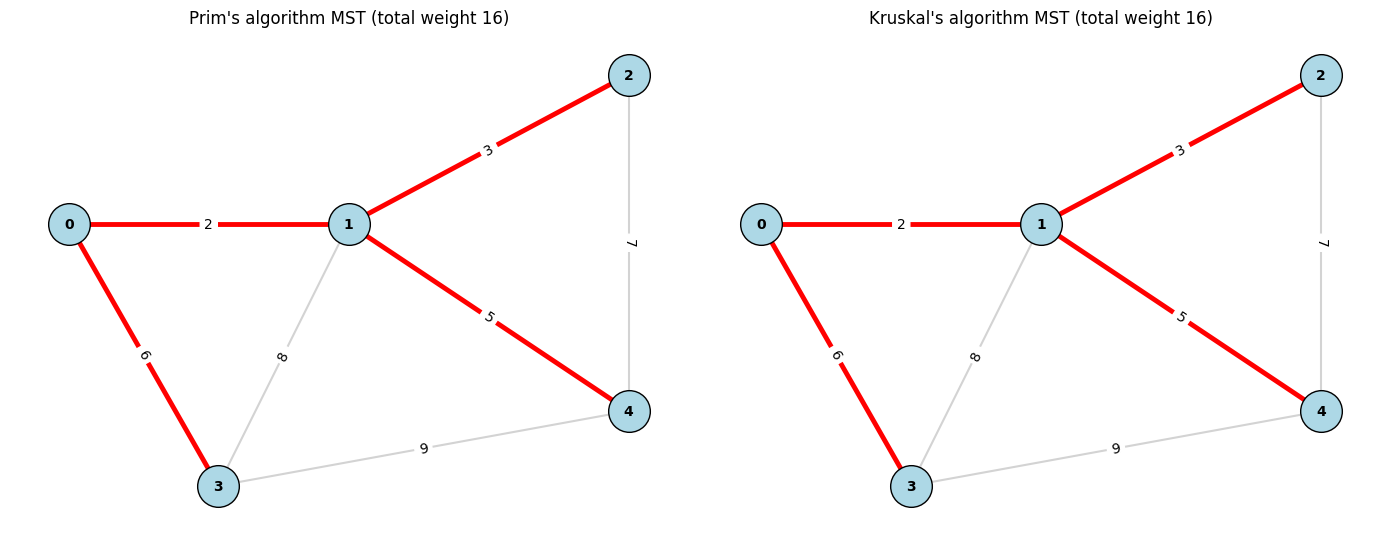

NetworkX prim    : total weight = 16.0   edges = [(0, 1), (0, 3), (1, 2), (1, 4)]
NetworkX kruskal : total weight = 16.0   edges = [(0, 1), (0, 3), (1, 2), (1, 4)]
Same MST from both of our algorithms: True
Number of MST edges = n - 1 = 4


In [ ]:
pos5 = {0: (0, 1), 1: (1.5, 1), 2: (3, 1.8), 3: (0.8, -0.4), 4: (3, 0)}

fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))
plot_graph_and_mst(ax[0], graph, prim_edges, f"Prim's algorithm MST (total weight {prim_total})", pos5)
plot_graph_and_mst(ax[1], graph, kruskal_edges, f"Kruskal's algorithm MST (total weight {kruskal_total})", pos5)
plt.tight_layout()
plt.show()

# independent check with NetworkX
G5 = nx.Graph(); G5.add_weighted_edges_from(edges)
for algo in ("prim", "kruskal"):
    T = nx.minimum_spanning_tree(G5, algorithm=algo)
    print(f"NetworkX {algo:8s}: total weight = {T.size(weight='weight')}   edges = {sorted(tuple(sorted(e)) for e in T.edges())}")
print("Same MST from both of our algorithms:", {frozenset((u, v)) for u, v, _ in prim_edges} == {frozenset((u, v)) for u, v, _ in kruskal_edges})
print("Number of MST edges = n - 1 =", len(prim_edges))

# **Application – cabling the buildings of a campus**

**Problem statement.** A campus network must connect six locations — HQ, Lab, Library, Hostel, Canteen and Gate — with optical fibre. The possible links and their lengths in metres are

| Link | HQ–Lab | HQ–Library | HQ–Hostel | Lab–Library | Lab–Canteen | Library–Hostel | Library–Canteen | Hostel–Canteen | Hostel–Gate | Canteen–Gate |
|---|---|---|---|---|---|---|---|---|---|---|
| Length (m) | 120 | 200 | 300 | 90 | 250 | 150 | 180 | 100 | 220 | 130 |

Find the set of links of minimum total length that connects all six locations, using both algorithms, and compare the length with the total of all possible links.

Prim's    MST: [('HQ', 'Lab', 120), ('Lab', 'Library', 90), ('Library', 'Hostel', 150), ('Hostel', 'Canteen', 100), ('Canteen', 'Gate', 130)] -> total 590 m
Kruskal's MST: [('Lab', 'Library', 90), ('Hostel', 'Canteen', 100), ('HQ', 'Lab', 120), ('Canteen', 'Gate', 130), ('Library', 'Hostel', 150)] -> total 590 m
Both algorithms give the same tree: True

Total length of all 10 possible links = 1740 m;   MST needs only 590 m  (saving of 1150 m = 66%).


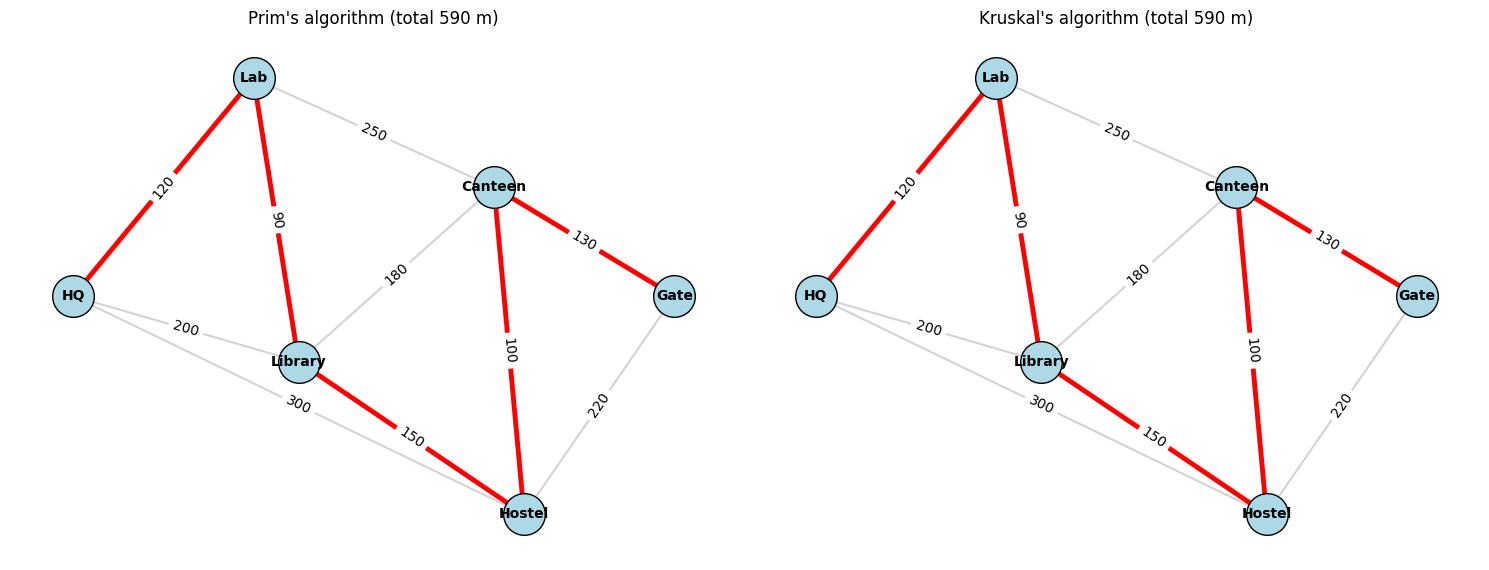

In [ ]:
names = ['HQ', 'Lab', 'Library', 'Hostel', 'Canteen', 'Gate']
idx = {nm: i for i, nm in enumerate(names)}
links = [('HQ', 'Lab', 120), ('HQ', 'Library', 200), ('HQ', 'Hostel', 300), ('Lab', 'Library', 90), ('Lab', 'Canteen', 250),
         ('Library', 'Hostel', 150), ('Library', 'Canteen', 180), ('Hostel', 'Canteen', 100), ('Hostel', 'Gate', 220), ('Canteen', 'Gate', 130)]

n6 = len(names)
edge_list = [(idx[a], idx[b], w) for a, b, w in links]
matrix = [[0] * n6 for _ in range(n6)]
for u, v, w in edge_list:
    matrix[u][v] = matrix[v][u] = w

p_edges, p_total, _ = prim_mst(matrix, start=0)
k_edges, k_total, k_steps = kruskal_mst(edge_list, n6)

print("Prim's    MST:", [(names[u], names[v], w) for u, v, w in p_edges], "-> total", p_total, "m")
print("Kruskal's MST:", [(names[u], names[v], w) for u, v, w in k_edges], "-> total", k_total, "m")
print("Both algorithms give the same tree:", {frozenset((u, v)) for u, v, _ in p_edges} == {frozenset((u, v)) for u, v, _ in k_edges})
all_links = sum(w for _, _, w in links)
print(f"\nTotal length of all {len(links)} possible links = {all_links} m;   MST needs only {k_total} m  "
      f"(saving of {all_links - k_total} m = {100 * (all_links - k_total) / all_links:.0f}%).")

pos6 = {0: (0, 1), 1: (1.2, 2), 2: (1.5, 0.7), 3: (3, 0), 4: (2.8, 1.5), 5: (4, 1)}
fig, ax = plt.subplots(1, 2, figsize=(15, 5.8))
plot_graph_and_mst(ax[0], matrix, p_edges, f"Prim's algorithm (total {p_total} m)", pos6, labels=dict(enumerate(names)))
plot_graph_and_mst(ax[1], matrix, k_edges, f"Kruskal's algorithm (total {k_total} m)", pos6, labels=dict(enumerate(names)))
plt.tight_layout()
plt.show()

# **Result**

* For the 5-vertex example both algorithms produced the same MST with the edges $\{0,1\}$ (2), $\{1,2\}$ (3), $\{1,4\}$ (5) and $\{0,3\}$ (6), of total weight **16**; NetworkX gave the same weight.
* For the campus network both algorithms selected the links Lab–Library (90), Hostel–Canteen (100), HQ–Lab (120), Canteen–Gate (130) and Library–Hostel (150), of total length **590 m**, against 1740 m for all possible links.

# **Discussion**

Prim's algorithm grows *one* tree from a start vertex, always taking the cheapest edge that leaves the tree; Kruskal's algorithm keeps *many* components and merges them by the cheapest edge that joins two different components. The trace tables show the difference in order but both end with $n-1$ edges and the same total weight — when all weights are distinct (as here) the MST is unique, so the two trees coincide. Prim's algorithm with a heap is usually preferred for dense graphs and Kruskal's for sparse graphs, where sorting the edge list is cheap. MSTs are used for the design of communication, electrical and road networks and as a first step in approximation algorithms for travelling-salesman-type problems.

# **Practice Problems**

**Problem 1.** Find the MST of the graph with edges $(0,1,4),(0,2,3),(1,2,1),(1,3,2),(2,3,4),(3,4,2),(4,5,6)$ by Kruskal's algorithm; list the order in which the edges are accepted and the edges rejected. Check with Prim's algorithm starting from vertex 3.

**Problem 2.** If two edges of a graph have the *same* weight, the MST may not be unique. Build a 4-cycle with all edges of weight 1, find its MSTs with Prim's algorithm starting from different vertices, and count how many different MSTs exist.

**Problem 3.** Modify the code to find a **maximum** spanning tree (use the negative weights or sort in descending order) of the campus graph. What is its total length?

**Problem 4.** Delete the edge Library–Hostel from the campus graph. Recompute the MST and the increase in cost.

---

# **EXPERIMENT 9**

---

# **Dijkstra's Algorithm for Shortest Path**

# **Aim:**

To understand and implement Dijkstra's algorithm to find the shortest path from a source node to all other nodes in a weighted graph, and to visualise the graph and the shortest paths.

# **Software required:**

Python 3, NetworkX, Matplotlib, Pandas, `heapq`

# **Problem statement:**

Write a Python program that uses Dijkstra's algorithm to compute the shortest path from a given source node to all other nodes in a weighted, connected and directed graph. Output the shortest path distances.

# **Theory:**

The **shortest-path problem** asks for a path of least total weight between vertices of a weighted graph. **Dijkstra's algorithm** solves the *single-source* problem when all edge weights are **non-negative**. It is a greedy algorithm: the vertex with the smallest tentative distance is *finalised* next, because no later path (using non-negative edges) can be shorter.

**Relaxation.** For an edge $(u,v)$ of weight $w$: if $d[u]+w<d[v]$ then set $d[v]=d[u]+w$ and remember $u$ as the predecessor of $v$. The predecessors form the **shortest-path tree**. With a binary heap the running time is $O((V+E)\log V)$.

# **Algorithm steps:**

1. Initialise the distance of the source node as 0 and all other nodes as infinity.
2. Create a priority queue (min-heap) to store nodes and their current shortest distances.
3. While the priority queue is not empty:
   * extract the node with the minimum distance;
   * update (relax) the distances of its neighbouring nodes;
   * push the neighbours with updated distances into the queue.
4. Repeat until all nodes have been visited or the queue is empty.

# **Dijkstra's algorithm with visualisation**

**Objective:** implement Dijkstra's algorithm in Python to find the shortest paths, and visualise the graph and the shortest-path distances.

The graph is stored as an **adjacency list**: `graph[u]` is a list of pairs `(neighbour, weight)`. The function returns the distances, the predecessor of each node, and a `log` that records every step. `reconstruct_path` follows the predecessors back from the target to the source.

In [ ]:
import heapq
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

# ------------------- Dijkstra's Algorithm -------------------
def dijkstra(graph, start):
    n = len(graph)                          # Step 1: total number of nodes
    distances = [float('inf')] * n          # Step 2: initialise distances to infinity
    distances[start] = 0                    # Step 3: distance to the source is 0
    priority_queue = [(0, start)]           # Step 4: min-heap of (tentative distance, node)
    previous_nodes = [None] * n             # Step 5: predecessor of each node
    log = []                                # trace of the run

    while priority_queue:                   # Step 6: until the queue is empty
        current_distance, current_node = heapq.heappop(priority_queue)
        if current_distance > distances[current_node]:      # Step 7: outdated entry -> skip
            continue
        relaxed = []
        for neighbor, weight in graph[current_node]:         # Step 8: examine the neighbours
            distance = current_distance + weight             # tentative distance through current_node
            if distance < distances[neighbor]:               # Step 9: shorter path found
                distances[neighbor] = distance
                previous_nodes[neighbor] = current_node
                heapq.heappush(priority_queue, (distance, neighbor))
                relaxed.append(f"d[{neighbor}] = {distance}")
        log.append({"Node finalised": current_node, "Distance": current_distance,
                    "Relaxed edges": ", ".join(relaxed) if relaxed else "none"})
    return distances, previous_nodes, log

# ------------------- Path reconstruction -------------------
def reconstruct_path(target_node, previous_nodes):
    path, current = [], target_node
    while current is not None:              # backtrack from the target to the source
        path.append(current)
        current = previous_nodes[current]
    path.reverse()                          # reverse to get source -> target
    return path

# **Example graph**

The directed graph is $0\to1$ (4), $0\to2$ (1), $2\to1$ (2), $1\to3$ (1), $2\to3$ (5). The direct edge $0\to1$ costs 4, but going through node 2 costs only $1+2=3$.

In [ ]:
# Graph defined using an adjacency list: node -> [(neighbour, weight), ...]
graph = {
    0: [(1, 4), (2, 1)],
    1: [(3, 1)],
    2: [(1, 2), (3, 5)],
    3: [],
}

source_node = 0
shortest_distances, previous_nodes, log = dijkstra(graph, source_node)

print("Shortest distances from node", source_node, "to all other nodes:", shortest_distances)
print("\nShortest paths:")
for node in graph:
    path = reconstruct_path(node, previous_nodes)
    print(f"  0 -> {node}:  {' -> '.join(map(str, path)):14s} distance = {shortest_distances[node]}")

print("\nStep-by-step trace of the algorithm:")
display(pd.DataFrame(log).rename_axis("Step").set_index(pd.RangeIndex(1, len(log) + 1, name="Step")))

Shortest distances from node 0 to all other nodes: [0, 3, 1, 4]

Shortest paths:
  0 -> 0:  0              distance = 0
  0 -> 1:  0 -> 2 -> 1    distance = 3
  0 -> 2:  0 -> 2         distance = 1
  0 -> 3:  0 -> 2 -> 1 -> 3 distance = 4

Step-by-step trace of the algorithm:


,Node finalised,Distance,Relaxed edges
Step,,,
1,0,0,"d[1] = 4, d[2] = 1"
2,2,1,"d[1] = 3, d[3] = 6"
3,1,3,d[3] = 4
4,3,4,none


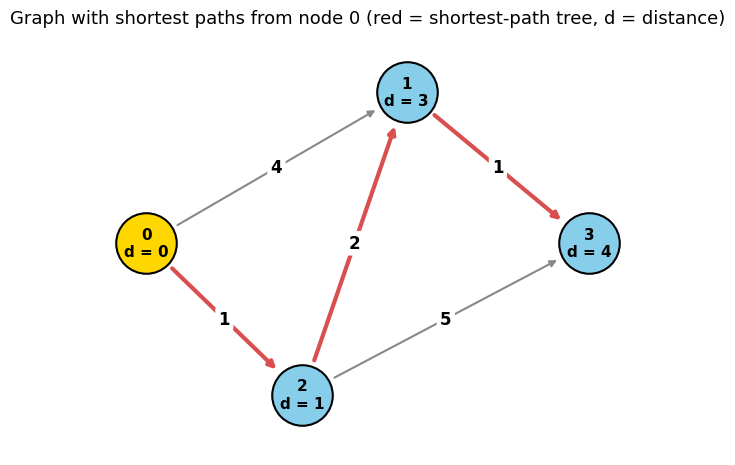

NetworkX distances: [0, 3, 1, 4]    same as ours: True


In [ ]:
def draw_digraph(ax, graph, pos, distances, previous_nodes, start, title):
    tree_edges = {(previous_nodes[v], v) for v in graph if previous_nodes[v] is not None}
    for u in graph:
        for v, w in graph[u]:
            on_tree = (u, v) in tree_edges
            ax.annotate("", xy=pos[v], xytext=pos[u],
                        arrowprops=dict(arrowstyle="-|>", lw=3 if on_tree else 1.5, color="#D94F4F" if on_tree else "#888",
                                        shrinkA=26, shrinkB=26), zorder=1)
            mx, my = (pos[u][0] + pos[v][0]) / 2, (pos[u][1] + pos[v][1]) / 2
            ax.text(mx, my, str(w), fontsize=12, fontweight='bold', ha='center', va='center',
                    bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none"), zorder=3)
    for node, (x, y) in pos.items():
        ax.scatter(x, y, s=1900, color='gold' if node == start else 'skyblue', edgecolors='k', linewidths=1.5, zorder=2)
        d = distances[node]
        ax.text(x, y, f"{node}\nd = {d}", ha='center', va='center', fontsize=11, fontweight='bold', zorder=4)
    ax.set_title(title, fontsize=13); ax.axis('off'); ax.margins(0.2)

pos4 = {0: (0, 0), 1: (2, 1.2), 2: (1.2, -1.2), 3: (3.4, 0)}
fig, ax = plt.subplots(figsize=(8, 5.5))
draw_digraph(ax, graph, pos4, shortest_distances, previous_nodes, source_node,
             "Graph with shortest paths from node 0 (red = shortest-path tree, d = distance)")
plt.show()

# independent check with NetworkX
DG = nx.DiGraph()
for u in graph:
    for v, w in graph[u]:
        DG.add_edge(u, v, weight=w)
nx_dist = nx.single_source_dijkstra_path_length(DG, 0)
print("NetworkX distances:", [nx_dist[i] for i in range(4)], "   same as ours:", [nx_dist[i] for i in range(4)] == shortest_distances)

# **Application – shortest routes in a road network**

**Problem statement.** Seven towns A–G are connected by two-way roads with the lengths (km): A–B 7, A–D 5, B–C 8, B–D 9, B–E 7, C–E 5, D–E 15, D–F 6, E–F 8, E–G 9, F–G 11. Find the shortest distance and route from town A to every other town.

A two-way road is stored as two directed edges.

,Shortest distance (km),Route
Destination,,
A,0,A
B,7,A → B
C,15,A → B → C
D,5,A → D
E,14,A → B → E
F,11,A → D → F
G,22,A → D → F → G


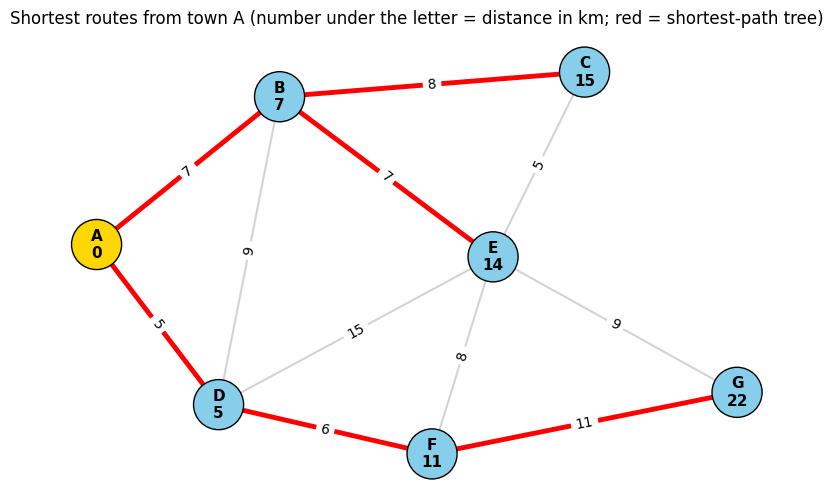

NetworkX check: True


In [ ]:
towns = "ABCDEFG"
roads = [('A', 'B', 7), ('A', 'D', 5), ('B', 'C', 8), ('B', 'D', 9), ('B', 'E', 7), ('C', 'E', 5),
         ('D', 'E', 15), ('D', 'F', 6), ('E', 'F', 8), ('E', 'G', 9), ('F', 'G', 11)]
idx = {t: i for i, t in enumerate(towns)}

road_graph = {i: [] for i in range(len(towns))}
for a, b, w in roads:                          # two-way roads: add both directions
    road_graph[idx[a]].append((idx[b], w))
    road_graph[idx[b]].append((idx[a], w))

dist, prev, _ = dijkstra(road_graph, idx['A'])
rows = []
for t in towns:
    route = " → ".join(towns[v] for v in reconstruct_path(idx[t], prev))
    rows.append({"Destination": t, "Shortest distance (km)": dist[idx[t]], "Route": route})
display(pd.DataFrame(rows).set_index("Destination"))

# draw the road network with the shortest-path tree from A in red
posT = {'A': (0, 1), 'B': (1.2, 2.2), 'C': (3.2, 2.4), 'D': (0.8, -0.3), 'E': (2.6, 0.9), 'F': (2.2, -0.7), 'G': (4.2, -0.2)}
RG = nx.Graph(); RG.add_weighted_edges_from(roads)
tree = {frozenset((towns[prev[v]], towns[v])) for v in range(len(towns)) if prev[v] is not None}
fig, ax = plt.subplots(figsize=(10, 6))
nx.draw_networkx_edges(RG, posT, edgelist=[e for e in RG.edges() if frozenset(e) not in tree], edge_color='lightgray', width=1.5, ax=ax)
nx.draw_networkx_edges(RG, posT, edgelist=[e for e in RG.edges() if frozenset(e) in tree], edge_color='red', width=3.5, ax=ax)
nx.draw_networkx_nodes(RG, posT, node_color=['gold' if t == 'A' else 'skyblue' for t in RG.nodes()], node_size=1300, edgecolors='k', ax=ax)
nx.draw_networkx_labels(RG, posT, labels={t: f"{t}\n{dist[idx[t]]}" for t in RG.nodes()}, font_size=11, font_weight='bold', ax=ax)
nx.draw_networkx_edge_labels(RG, posT, edge_labels=nx.get_edge_attributes(RG, 'weight'), font_size=10, ax=ax)
ax.set_title("Shortest routes from town A (number under the letter = distance in km; red = shortest-path tree)"); ax.axis('off')
plt.show()
print("NetworkX check:", nx.single_source_dijkstra_path_length(RG, 'A') == {t: dist[idx[t]] for t in towns})

# **A warning – negative edge weights**

Dijkstra's algorithm is correct only when **all weights are non-negative**. In the graph $0\to1$ (2), $0\to2$ (3), $2\to1$ ($-2$), $1\to3$ (1) the true shortest distance to node 1 is $3-2=1$ (via node 2) and to node 3 is 2. The classic version of Dijkstra's algorithm, which never revisits a finalised node, finalises node 1 with distance 2 *before* it discovers the cheaper route, and so gives wrong answers. The **Bellman–Ford** algorithm handles negative weights (as long as there is no negative cycle).

In [ ]:
def dijkstra_classic(graph, start):
    """Classic Dijkstra: a node is finalised when popped and never updated again."""
    n = len(graph); dist = [float('inf')] * n; dist[start] = 0
    done = [False] * n; pq = [(0, start)]
    while pq:
        d, u = heapq.heappop(pq)
        if done[u]:
            continue
        done[u] = True
        for v, w in graph[u]:
            if not done[v] and d + w < dist[v]:
                dist[v] = d + w
                heapq.heappush(pq, (dist[v], v))
    return dist

neg_graph = {0: [(1, 2), (2, 3)], 1: [(3, 1)], 2: [(1, -2)], 3: []}
NG = nx.DiGraph([(u, v, {"weight": w}) for u in neg_graph for v, w in neg_graph[u]])
bellman = nx.single_source_bellman_ford_path_length(NG, 0)

print("Classic Dijkstra  :", dijkstra_classic(neg_graph, 0), "   <- wrong for nodes 1 and 3")
print("Bellman-Ford      :", [bellman[i] for i in range(4)], "   <- correct")

Classic Dijkstra  : [0, 2, 3, 3]    <- wrong for nodes 1 and 3
Bellman-Ford      : [0, 1, 3, 2]    <- correct


# **Result**

* For the example digraph the shortest distances from node 0 are $[0,\,3,\,1,\,4]$: node 1 is reached via $0\to2\to1$ (cost 3, not the direct edge of cost 4) and node 3 via $0\to2\to1\to3$ (cost 4). The result agreed with NetworkX.
* In the road network the shortest distances from A are B 7, C 15, D 5, E 14, F 11 and G 22 km; for example E is reached by A → B → E (14 km) and G by A → D → F → G (22 km), which is shorter than going through E (23 km).
* A negative edge weight made the classic Dijkstra algorithm give wrong answers whereas Bellman–Ford gave the correct distances.

# **Discussion**

Dijkstra's algorithm repeatedly *finalises* the closest unfinalised vertex and *relaxes* its outgoing edges; the heap makes the choice of the closest vertex efficient. The trace table shows that distances are only *tentative* until the vertex is popped — for example $d[1]=4$ is improved to $3$ after node 2 is processed. The predecessor array gives the whole shortest-path *tree*, not only the length, so any route can be recovered with `reconstruct_path`. The correctness argument (a finalised vertex cannot be improved) breaks down with negative weights; with such weights the Bellman–Ford algorithm ($O(VE)$) must be used instead. Dijkstra's algorithm is the basis of routing protocols such as OSPF and of map and navigation software.

# **Practice Problems**

**Problem 1.** For the graph with edges $0\to1$ (7), $0\to2$ (9), $0\to5$ (14), $1\to2$ (10), $1\to3$ (15), $2\to3$ (11), $2\to5$ (2), $3\to4$ (6), $5\to4$ (9), find the shortest distance and the route from node 0 to every other node.

**Problem 2.** Modify `dijkstra` so that it stops as soon as a given *target* node is popped from the heap, and count how many nodes are finalised for the targets 1 and 3 in the example graph.

**Problem 3.** In the road network, close the road D–F. Recompute the distances from A. Which destinations become farther away and by how much?

**Problem 4.** Run `dijkstra_classic` on a graph that contains a negative edge but gives the *correct* answer (for example $0\to1$ (4), $1\to2$ ($-1$)). Explain why it works here but not in general.

---

# **EXPERIMENT 10**

---

# **Graph Colouring Using the Greedy Algorithm**

# **Aim:**

To understand and implement the greedy algorithm for graph colouring, to visualise the graph with coloured vertices, and to study how the order of the vertices affects the number of colours used.

# **Software required:**

Python 3, NetworkX, Matplotlib, Pandas

# **Problem statement:**

Write a Python program to colour the nodes of a given graph using the greedy graph-colouring algorithm. The program should minimise the number of colours while ensuring that no two adjacent nodes share the same colour.

# **Theory:**

A **proper vertex colouring** assigns a colour to every vertex so that **adjacent vertices have different colours**. The least number of colours needed is the **chromatic number** $\chi(G)$. Finding $\chi(G)$ is NP-hard, so in practice a *greedy* heuristic is used.

* **Bounds:** $\omega(G)\le\chi(G)\le\Delta(G)+1$, where $\omega$ is the size of the largest clique (complete subgraph) and $\Delta$ the maximum degree. The greedy algorithm never uses more than $\Delta+1$ colours.
* **Special cases:** a bipartite graph has $\chi=2$; an odd cycle has $\chi=3$; the complete graph $K_n$ has $\chi=n$; every planar graph is 4-colourable (Four Colour Theorem).
* **Greedy algorithm:** take the vertices in some order and give each vertex the **smallest colour not used by its already-coloured neighbours**. The result **depends on the order**; ordering the vertices by decreasing degree (the *Welsh–Powell* order) usually gives good results.
* **Applications:** timetabling and scheduling, register allocation in compilers, map colouring, frequency assignment.

# **Algorithm steps:**

1. Arrange the nodes in some order (in the greedy approach the order can affect the result).
2. Assign the smallest possible colour to each node such that no two adjacent nodes have the same colour.
3. Track the colour assignments to ensure the validity of the solution.

# **The greedy colouring function**

* `color_assignment` is a dictionary `node → colour (0, 1, 2, …)`.
* For every node the colours of its neighbours that are already coloured are collected, and the smallest integer not among them is assigned.
* The optional argument `order` lets us choose the order of the nodes.
* `is_proper` checks the result: no edge may join two vertices of the same colour.

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

# ------------------- Graph colouring function -------------------
def greedy_graph_coloring(graph, order=None):
    color_assignment = {}                                        # Step 1: node -> colour
    for node in (order if order is not None else graph.nodes()): # Step 2: loop through the nodes in the given order
        adjacent_colors = {color_assignment[nb] for nb in graph.neighbors(node) if nb in color_assignment}   # Step 3
        color = 0
        while color in adjacent_colors:                          # Step 4: smallest colour not used by a neighbour
            color += 1
        color_assignment[node] = color
    return color_assignment

def is_proper(graph, color_assignment):
    return all(color_assignment[u] != color_assignment[v] for u, v in graph.edges())

PALETTE = ['#E4572E', '#4C9BE8', '#76B041', '#F2A33A', '#9B5DE5', '#00BBF9', '#F15BB5', '#8D99AE']

def plot_colored_graph(graph, color_assignment, ax, title, pos=None):
    pos = pos if pos is not None else nx.spring_layout(graph, seed=4)
    colors = [PALETTE[color_assignment[n] % len(PALETTE)] for n in graph.nodes()]
    nx.draw(graph, pos, with_labels=True, node_color=colors, node_size=1300, font_size=12, font_weight='bold',
            edge_color='black', width=1.5, ax=ax)
    ax.set_title(title, fontsize=13)

# **Sample graph**

The edges (pairs of conflicting nodes) are $(0,1),(0,2),(1,2),(1,3),(2,3),(3,4)$. Nodes 0, 1, 2 form a triangle, so at least 3 colours are needed.

Node colour assignment: {0: 0, 1: 1, 2: 2, 3: 0, 4: 1}
Number of colours used : 3
Proper colouring       : True
Largest clique size ω = 3  ->  at least 3 colours are needed; greedy used 3: the colouring is optimal (χ = 3).
Upper bound Δ + 1 = 4


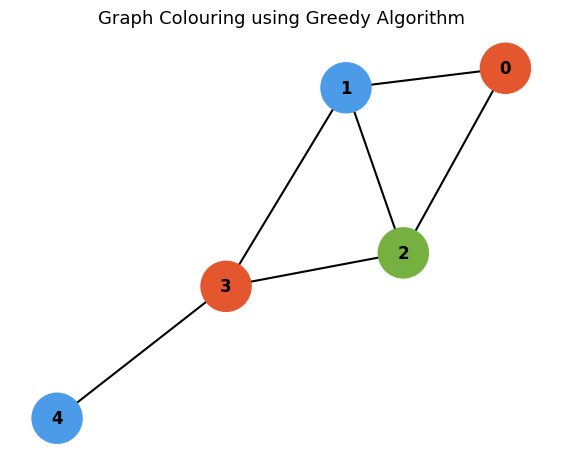

In [ ]:
# Step 1: define the edges of the graph (conflicting pairs)
edges = [(0, 1), (0, 2), (1, 2), (1, 3), (2, 3), (3, 4)]

# Step 2: create a NetworkX graph and add the edges
G = nx.Graph()
G.add_edges_from(edges)

# Run the greedy colouring
color_assignment = greedy_graph_coloring(G)

# Step 3: print the result
print("Node colour assignment:", color_assignment)
print("Number of colours used :", len(set(color_assignment.values())))
print("Proper colouring       :", is_proper(G, color_assignment))
omega = max(len(c) for c in nx.find_cliques(G))
print(f"Largest clique size ω = {omega}  ->  at least {omega} colours are needed; greedy used {len(set(color_assignment.values()))}: the colouring is optimal (χ = {omega}).")
print("Upper bound Δ + 1 =", max(d for _, d in G.degree()) + 1)

# Step 4: plot the coloured graph
fig, ax = plt.subplots(figsize=(7, 5.5))
plot_colored_graph(G, color_assignment, ax, "Graph Colouring using Greedy Algorithm")
plt.show()

# **The effect of the vertex order**

Greedy colouring is only a heuristic. The **crown graph** shows how bad it can be: take vertices $a_0,\dots,a_{n-1}$ and $b_0,\dots,b_{n-1}$ and join $a_i$ to $b_j$ whenever $i\ne j$. The graph is bipartite, so $\chi=2$. If the vertices are taken in the order $a_0,b_0,a_1,b_1,\dots$ the greedy algorithm uses $n$ colours; if all $a$'s are taken first and then all $b$'s, it uses 2.

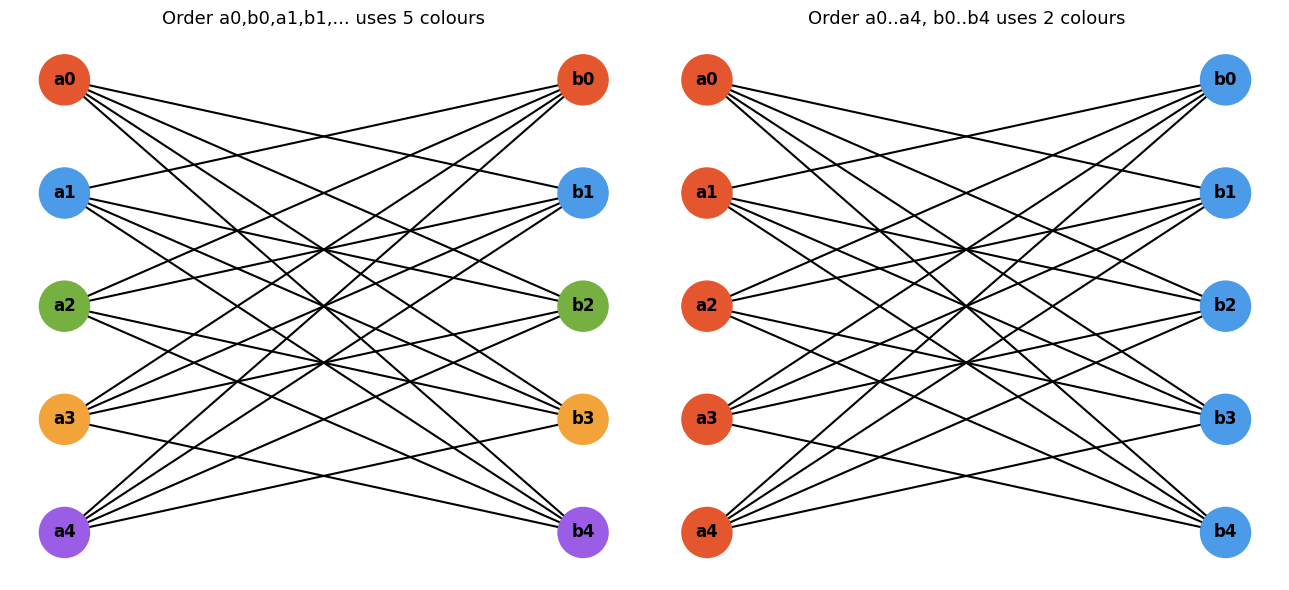

,vertices,χ (bipartite),"greedy, bad order","greedy, good order"
k,,,,
2,4,2,2,2
3,6,2,3,2
4,8,2,4,2
5,10,2,5,2
6,12,2,6,2
7,14,2,7,2
8,16,2,8,2


In [ ]:
def crown_graph(k):
    C = nx.Graph()
    C.add_nodes_from([f"a{i}" for i in range(k)] + [f"b{i}" for i in range(k)])
    C.add_edges_from((f"a{i}", f"b{j}") for i in range(k) for j in range(k) if i != j)
    return C

k = 5
C = crown_graph(k)
bad_order  = [x for i in range(k) for x in (f"a{i}", f"b{i}")]               # a0, b0, a1, b1, ...
good_order = [f"a{i}" for i in range(k)] + [f"b{i}" for i in range(k)]       # a0..a4, b0..b4
col_bad, col_good = greedy_graph_coloring(C, bad_order), greedy_graph_coloring(C, good_order)

posC = {f"a{i}": (0, -i) for i in range(k)} | {f"b{i}": (2, -i) for i in range(k)}
fig, ax = plt.subplots(1, 2, figsize=(13, 6))
plot_colored_graph(C, col_bad, ax[0], f"Order a0,b0,a1,b1,... uses {len(set(col_bad.values()))} colours", posC)
plot_colored_graph(C, col_good, ax[1], f"Order a0..a4, b0..b4 uses {len(set(col_good.values()))} colours", posC)
plt.tight_layout()
plt.show()

rows = []
for kk in range(2, 9):
    Ck = crown_graph(kk)
    o_bad = [x for i in range(kk) for x in (f"a{i}", f"b{i}")]
    o_good = [f"a{i}" for i in range(kk)] + [f"b{i}" for i in range(kk)]
    rows.append({"k": kk, "vertices": 2 * kk, "χ (bipartite)": 2,
                 "greedy, bad order": len(set(greedy_graph_coloring(Ck, o_bad).values())),
                 "greedy, good order": len(set(greedy_graph_coloring(Ck, o_good).values()))})
display(pd.DataFrame(rows).set_index("k"))

# **Ordering strategies on a random graph**

NetworkX's `nx.greedy_color` provides several ordering strategies. They are compared on a random graph with 30 vertices and edge probability 0.2, together with the lower bound $\omega$ (largest clique) and the upper bound $\Delta+1$. *Largest first* is the Welsh–Powell order; *DSATUR* (saturation largest first) chooses the vertex with the most distinctly-coloured neighbours.

In [ ]:
R = nx.gnp_random_graph(30, 0.2, seed=2)
omega_R = max(len(c) for c in nx.find_cliques(R))
delta_R = max(d for _, d in R.degree())

import random
random.seed(1)                                   # makes the 'random_sequential' strategy reproducible
rows = [{"Strategy": "natural order (0, 1, 2, ...)", "colours": len(set(greedy_graph_coloring(R).values()))}]
for strategy in ("largest_first", "smallest_last", "saturation_largest_first", "random_sequential"):
    rows.append({"Strategy": strategy, "colours": len(set(nx.greedy_color(R, strategy=strategy).values()))})
table = pd.DataFrame(rows).set_index("Strategy")
display(table)
print(f"Random graph: {R.number_of_nodes()} vertices, {R.number_of_edges()} edges, maximum degree Δ = {delta_R}")
print(f"Lower bound ω = {omega_R};   upper bound Δ + 1 = {delta_R + 1};   so  {omega_R} ≤ χ ≤ {table['colours'].min()} (best greedy result)")

,colours
Strategy,
"natural order (0, 1, 2, ...)",6
largest_first,6
smallest_last,4
saturation_largest_first,4
random_sequential,4


Random graph: 30 vertices, 84 edges, maximum degree Δ = 10
Lower bound ω = 4;   upper bound Δ + 1 = 11;   so  4 ≤ χ ≤ 4 (best greedy result)


# **Application 1 – Scheduling examinations**

**Problem statement.** Seven courses must be scheduled into examination slots. Two courses that have a student in common cannot be held in the same slot. The conflicting pairs are Maths–Physics, Maths–CS, Maths–English, Physics–Chemistry, Physics–Electronics, Chemistry–Biology, CS–Electronics, CS–English and Electronics–English. Find a timetable with as few slots as possible.

Each course is a vertex, each conflict an edge, and each colour a time slot. The vertices are coloured in order of decreasing degree (Welsh–Powell).

Order used (decreasing degree): ['Maths', 'Physics', 'CS', 'English', 'Electronics', 'Chemistry', 'Biology']
Proper colouring: True    Number of slots needed: 3   (largest clique ω = 3 )

Examination timetable:
  Slot 1:  Maths, Chemistry, Electronics
  Slot 2:  Physics, CS, Biology
  Slot 3:  English


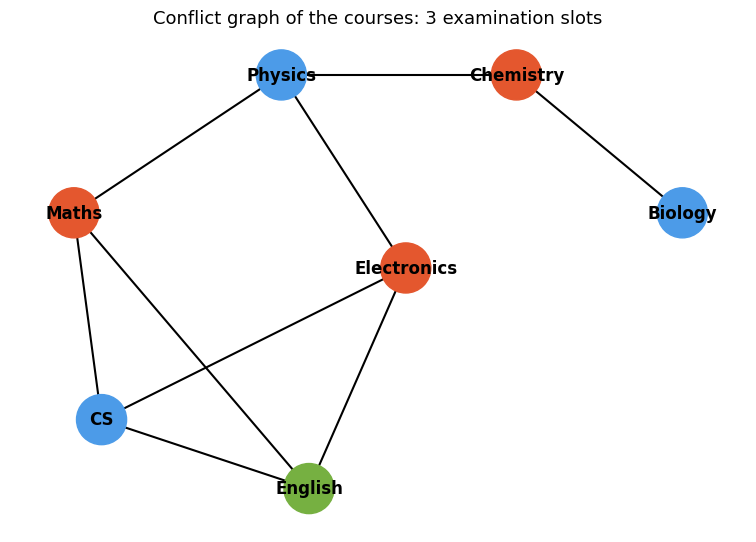

In [ ]:
courses = ['Maths', 'Physics', 'Chemistry', 'CS', 'English', 'Electronics', 'Biology']
conflicts = [('Maths', 'Physics'), ('Maths', 'CS'), ('Maths', 'English'), ('Physics', 'Chemistry'), ('Physics', 'Electronics'),
             ('Chemistry', 'Biology'), ('CS', 'Electronics'), ('CS', 'English'), ('Electronics', 'English')]
T = nx.Graph(); T.add_nodes_from(courses); T.add_edges_from(conflicts)

order = sorted(T.nodes(), key=lambda v: -T.degree(v))                 # Welsh-Powell: largest degree first
slots = greedy_graph_coloring(T, order)
n_slots = len(set(slots.values()))

print("Order used (decreasing degree):", order)
print("Proper colouring:", is_proper(T, slots), "   Number of slots needed:", n_slots, "  (largest clique ω =", max(len(c) for c in nx.find_cliques(T)), ")")
print("\nExamination timetable:")
for s in range(n_slots):
    print(f"  Slot {s + 1}: ", ", ".join(c for c in courses if slots[c] == s))

posT = {'Maths': (0, 1), 'Physics': (1.5, 2), 'Chemistry': (3.2, 2), 'CS': (0.2, -0.5), 'English': (1.7, -1.0),
        'Electronics': (2.4, 0.6), 'Biology': (4.4, 1)}
fig, ax = plt.subplots(figsize=(9.5, 6.5))
plot_colored_graph(T, slots, ax, f"Conflict graph of the courses: {n_slots} examination slots", posT)
plt.show()

# **Application 2 – Colouring a map**

**Problem statement.** Colour the states of Australia so that states with a common border get different colours. The borders are WA–NT, WA–SA, NT–SA, NT–Q, SA–Q, SA–NSW, SA–V, Q–NSW and NSW–V; Tasmania (T) has no land border. Find the minimum number of colours.

Colouring: {'SA': 'red', 'NT': 'blue', 'Q': 'green', 'NSW': 'blue', 'WA': 'green', 'V': 'green', 'T': 'red'}
Proper: True    colours used: 3   largest clique ω = 3  -> 3 colours are enough and necessary.


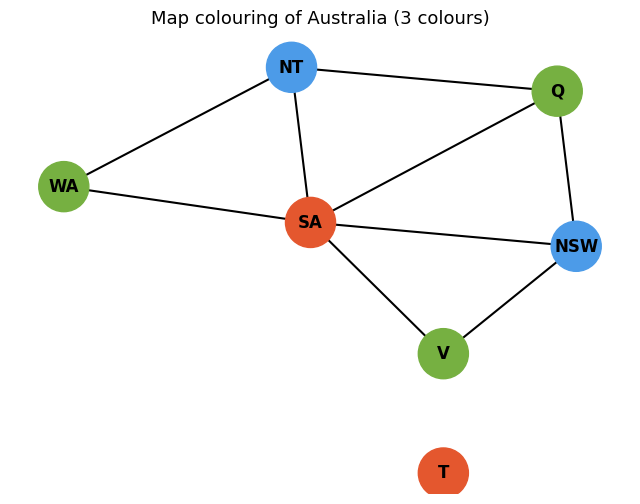

In [ ]:
borders = [('WA', 'NT'), ('WA', 'SA'), ('NT', 'SA'), ('NT', 'Q'), ('SA', 'Q'), ('SA', 'NSW'), ('SA', 'V'), ('Q', 'NSW'), ('NSW', 'V')]
M = nx.Graph(); M.add_nodes_from(['WA', 'NT', 'SA', 'Q', 'NSW', 'V', 'T']); M.add_edges_from(borders)

order = sorted(M.nodes(), key=lambda v: -M.degree(v))
map_colors = greedy_graph_coloring(M, order)
names = ['red', 'blue', 'green', 'orange']
print("Colouring:", {s: names[c] for s, c in map_colors.items()})
print("Proper:", is_proper(M, map_colors), "   colours used:", len(set(map_colors.values())),
      "  largest clique ω =", max(len(c) for c in nx.find_cliques(M)), " -> 3 colours are enough and necessary.")

posM = {'WA': (0, 1.5), 'NT': (1.2, 2.5), 'Q': (2.6, 2.3), 'SA': (1.3, 1.2), 'NSW': (2.7, 1.0), 'V': (2.0, 0.1), 'T': (2.0, -0.9)}
fig, ax = plt.subplots(figsize=(8, 6))
plot_colored_graph(M, map_colors, ax, "Map colouring of Australia (3 colours)", posM)
plt.show()

# **Result**

* The sample graph (triangle 0-1-2 plus nodes 3 and 4) was coloured with the assignment $\{0:0,\,1:1,\,2:2,\,3:0,\,4:1\}$ using **3 colours**; the colouring is proper and optimal because the graph contains a triangle ($\omega=3$).
* On the crown graph the order $a_0,b_0,a_1,b_1,\dots$ made greedy use $k$ colours for a bipartite graph, while the order $a$'s-then-$b$'s used 2.
* On a random graph with 30 vertices the natural and largest-first orders used 6 colours while smallest-last and DSATUR used 4, which equals the clique number $\omega=4$ — so $\chi=4$ exactly.
* The examination timetable needed 3 slots and the map of Australia was coloured with 3 colours; both colourings were verified to be proper.

# **Discussion**

The greedy algorithm is fast ($O(V+E)$ for a given order) and always produces a proper colouring with at most $\Delta+1$ colours, but it does **not** guarantee the minimum: the crown graph, a bipartite graph that can be forced to use arbitrarily many colours, shows that the *order* matters. Heuristic orders — largest degree first, smallest last, saturation (DSATUR) — usually give much better results, and the clique number gives a lower bound that certifies optimality when it is reached, as in the sample graph and both applications. Graph colouring is the mathematical model of every "conflict-free allocation" problem: examination timetables (colours = slots), register allocation (colours = registers), frequency assignment and map colouring.

# **Practice Problems**

**Problem 1.** Colour the cycle graphs $C_4$, $C_5$ and $C_6$ with the greedy algorithm. How many colours does each need? Explain the difference between even and odd cycles and check with `nx.is_bipartite`.

**Problem 2.** Find a colouring of the Petersen graph (`nx.petersen_graph()`) with the greedy algorithm under different vertex orders. What is the smallest number of colours you can obtain? (It is known that $\chi=3$.)

**Problem 3.** Six radio stations A–F interfere with each other as follows: A–B, A–C, B–C, B–D, C–E, D–E, D–F, E–F. Assign frequencies (colours) so that interfering stations use different frequencies, with the least number of frequencies. Verify the result with `is_proper`.

**Problem 4.** Using the crown graph with $k=6$, find another vertex order (not the two orders of this experiment) that makes greedy use exactly 3 colours.